## read train2

In [434]:
import numpy as np
import pandas as pd
from sympy import limit
import wandb

api = wandb.Api(
    api_key="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",
    timeout=60
)

# 1. Get last 10 runs (sorted by creation time descending)
runs = api.runs(
    "eibl-usc/graph-clip",
    filters={
        # "display_name": {"$regex": "trained_on_.._eval_on_.._..?_shot_.+"},
        # "config.dataset": "ukr_rus_twitter",
        # "config.task_name": "neighbor_matching",
    },
    order="-created_at",
    per_page=10,
    # limit to 10:
    lazy=False
)

In [1604]:
rows = []
for run in runs:
    attrs = getattr(run, "_attrs", {}) or {}
    params = ((attrs.get("config") or {}).get("params") or {})
    summary = attrs.get("summaryMetrics") or {}

    rows.append({
        "run_id": attrs.get("name"),
        "display_name": attrs.get("displayName"),
        "state": attrs.get("state"),
        "dataset": params.get("dataset"),
        "task_name": params.get("task_name"),
        "prefix": params.get("prefix"),
        "pretrained_model_run": params.get("pretrained_model_run"),
        "n_shots": params.get("n_shots"),
        "n_way": params.get("n_way"),
        "n_query": params.get("n_query"),
        "zero_shot": params.get("zero_shot"),
        "test_accuracy": summary.get("test_accuracy"),
        "train_accuracy": summary.get("train_accuracy"),
        "test_f1": summary.get("test_f1"),
        "test_roc_auc": summary.get("test_roc_auc"),
        "created_at": attrs.get("createdAt"),
        'steps': attrs['historyKeys']['keys'].get('_step', {}).get('typeCounts', [{}])[0].get('count', np.nan),
        'tags': attrs.get("tags", []),
        'input_dim': params.get("input_dim"),
        'eval_only': params.get("eval_only"),
    })
df = pd.DataFrame(rows)
df["task_name"] = df["task_name"].map({
    "neighbor_matching": "nm",
    "temporal_link_prediction": "lp",
    "classification": "pl",
})
df['created_at'] = pd.to_datetime(df['created_at'])
df["shot_label"] = df.apply(lambda r: 0 if bool(r.get("zero_shot", False)) else r["n_shots"], axis=1)
# df['is_eval'] = df['display_name'].str.contains(r"eval")
# plot_df = df[df["eval1_task"].isin(EVAL_TASKS) & df["train1_task"].eq("nm")].copy()
df['eval1_dataset'] = df['dataset']
df['trained_on_display_name'] = df.pretrained_model_run.str.findall("(.+)/(.+)/((checkpoint/(.+)\.ckpt)|state_dict)$").str[0].str[1]
df['month/day'] = df['created_at'].dt.month.astype(str) + '/' + df['created_at'].dt.day.astype(str)
df = df.sort_values('created_at', ascending=False)
mask = df['trained_on_display_name'].isin(df['display_name'])
existing_trained_on_display_names = df.trained_on_display_name[mask]
df__ = df.copy()

In [ ]:
# df.to_csv('all_runs_apr_28_eod.csv')

In [ ]:
ts = df[df.tags.astype(str).str.contains('remaining_train2_eval_04_27')]['created_at']

start, end = ts.min(), ts.max()   # safer than assuming order
df = df[df['created_at'].between(start, end)]

In [ ]:
# df.to_csv("remaining_train2_eval_04_27.csv")

## process

In [1260]:
train2_remaining = pd.read_csv("remaining_train2_eval_04_27.csv")


pat = (
    r"eval_exp..?_"
    r"(?P<train1_dataset>.+)_(?P<train1_task>nm|lp|pl)_to_"
    r"(?P<train2_dataset>.+)_(?P<train2_task>nm|lp|pl)_to_"
    r"(?P<eval_dataset>.+)_(?P<eval_task>nm|lp|pl)_"
    r"(?P<shots>..?)shot_27_04_2026"
)

extracted = train2_remaining["display_name"].str.extract(pat)

train2_remaining = pd.concat([train2_remaining, extracted], axis=1)

rd = {
    "covid": 'covid19_twitter',
    "ukr_rus": "ukr_rus_twitter",
}
train2_remaining['train1_dataset'] = train2_remaining.train1_dataset.str.replace(rd)

train2_remaining['train2_dataset'] = train2_remaining.train2_dataset.str.replace(rd)

train2_remaining['train1_tuple'] = train2_remaining["train1_dataset"] + "+" + train2_remaining["train1_task"]
train2_remaining['train2_tuple'] = train2_remaining["train2_dataset"] + "+" + train2_remaining["train2_task"]
train2_remaining['train_id'] = (train2_remaining.train1_tuple + ">" + train2_remaining.train2_tuple)
train2_remaining['eval_id'] = train2_remaining["eval_dataset"] + "+" + train2_remaining["eval_task"]

train2_remaining["seq_id"] = (
    train2_remaining.train_id + "|" + train2_remaining.eval_id
)


train2_remaining["n_shots"] = pd.to_numeric(train2_remaining["n_shots"])
train2_remaining["shots"] = pd.to_numeric(train2_remaining["n_shots"]).astype(int)

# optional: make train labels prettier
train2_remaining["train_label"] = train2_remaining["train_id"]

train2_remaining = train2_remaining[~train2_remaining.display_name.str.startswith("train1_covid19_twitt")]

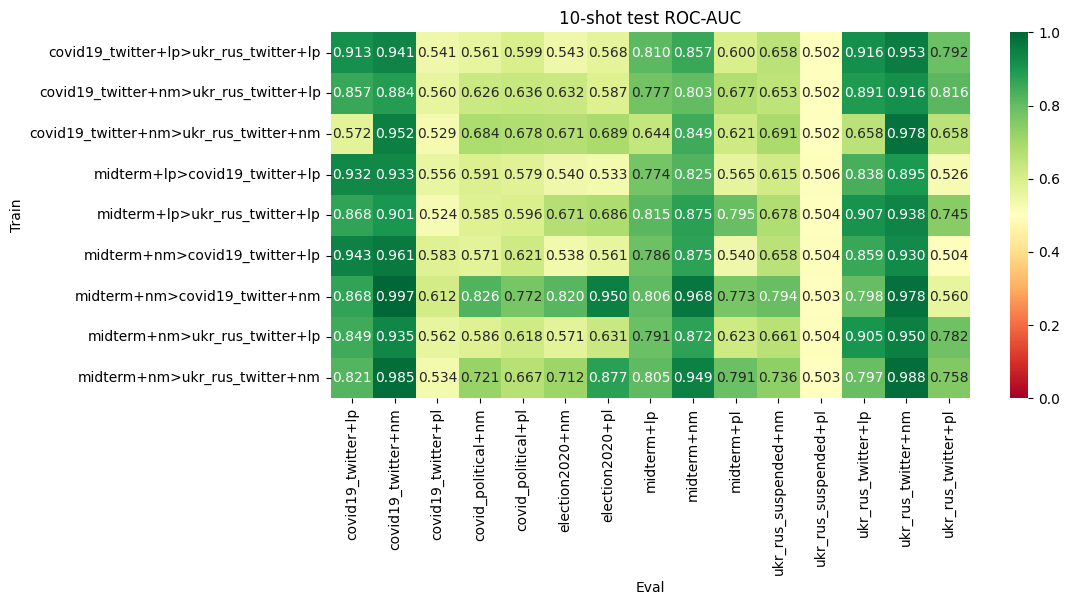

In [1261]:
import seaborn as sns
import matplotlib.pyplot as plt


# only 10-shot
d10 = train2_remaining[train2_remaining["shots"].astype(str).eq("3")].copy()

# heatmap matrix
mat = d10.pivot_table(
    index="train_id",
    columns="eval_id",
    values="test_roc_auc",
    aggfunc="mean",   # handles duplicate runs
)

plt.figure(figsize=(0.5 * mat.shape[1] + 4, 0.35 * mat.shape[0] + 3))
sns.heatmap(mat, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0, vmax=1)
plt.xlabel("Eval")
plt.ylabel("Train")
plt.title("10-shot test ROC-AUC")
plt.tight_layout()
plt.show()

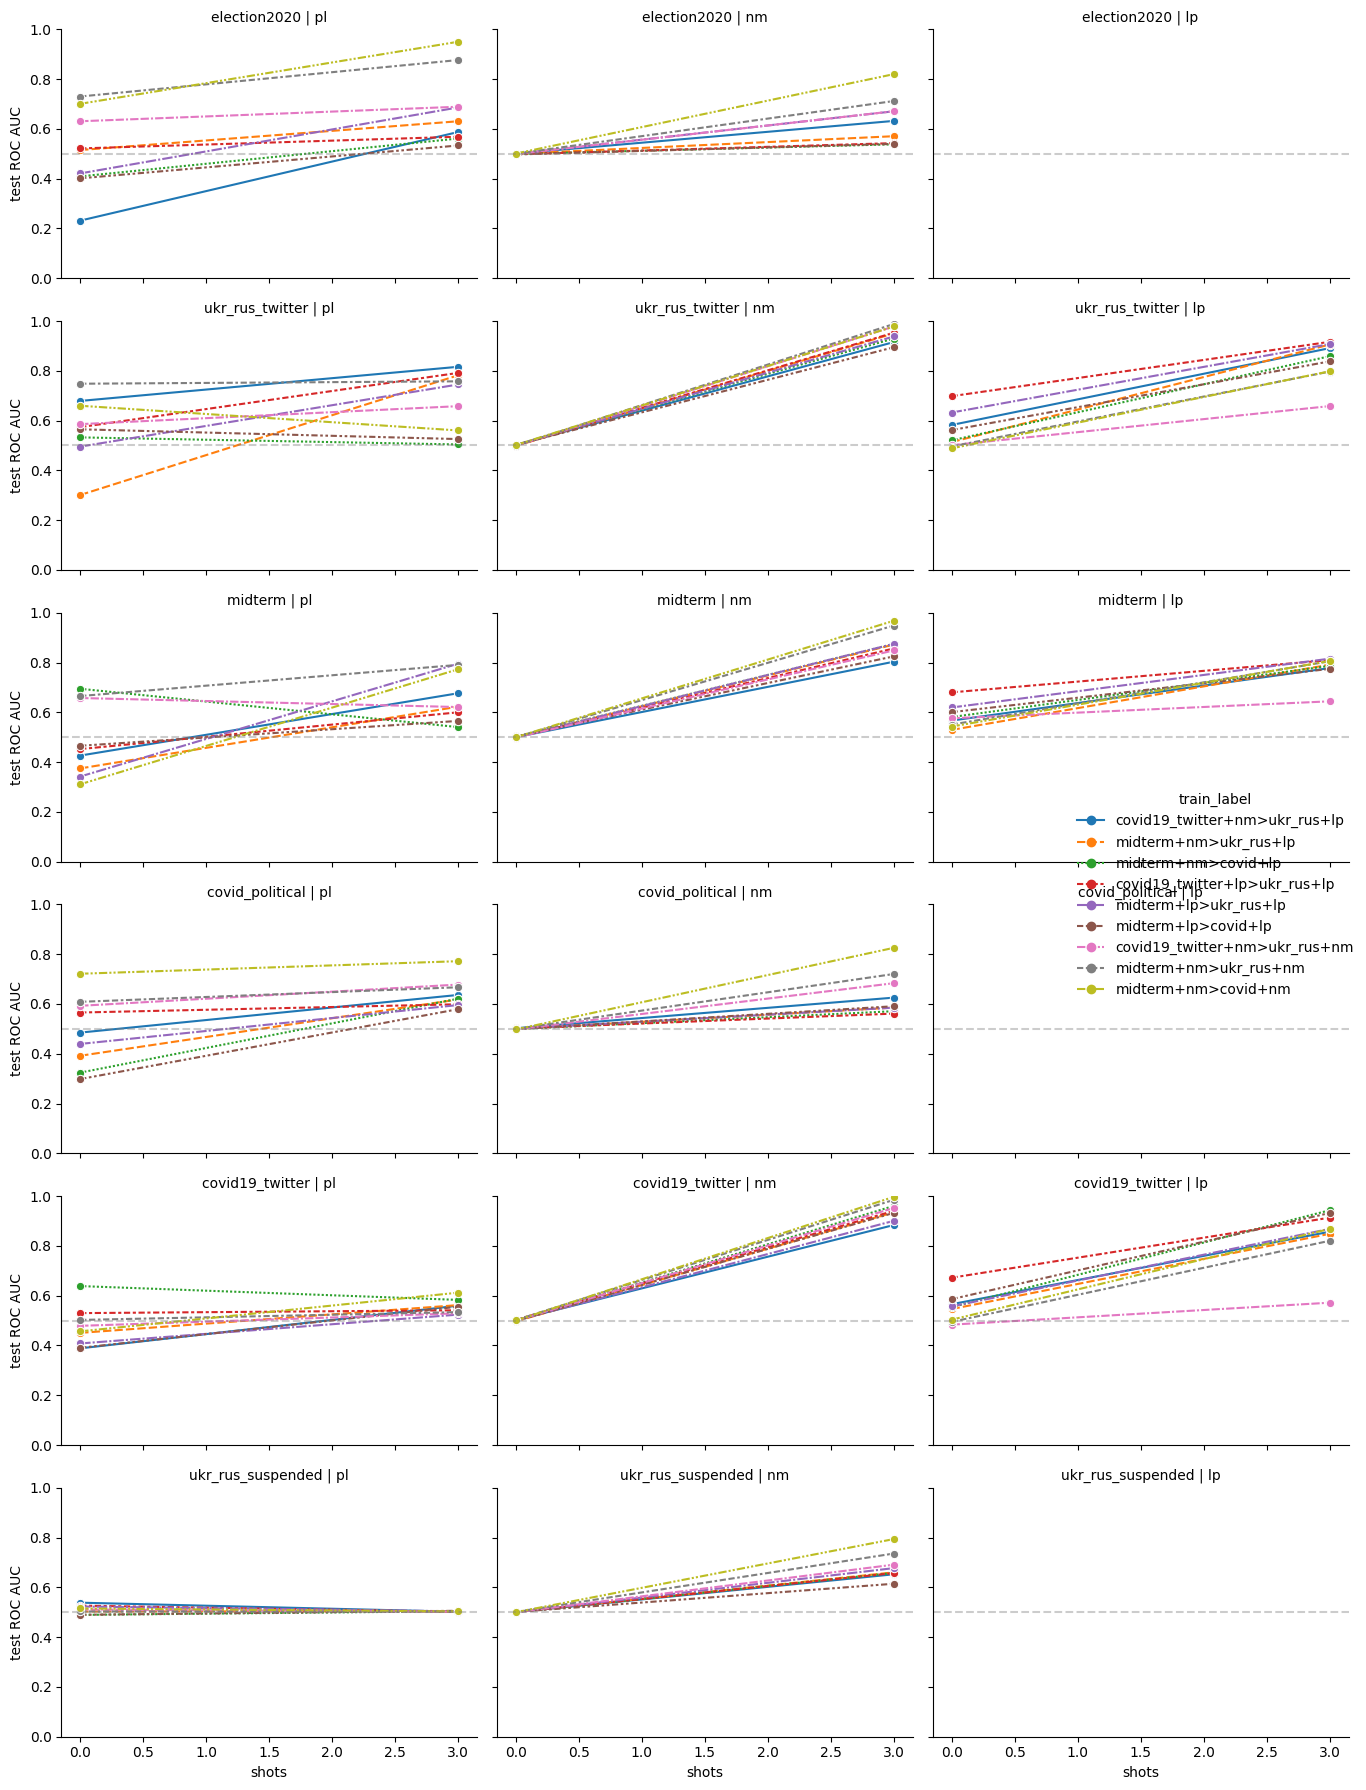

In [1193]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


g = sns.relplot(
    data=train2_remaining,
    x="shots",
    y="test_roc_auc",
    hue="train_label",
    style="train_label",
    row="eval_dataset",
    col="eval_task",
    kind="line",
    marker="o",
    estimator=None,   # plot raw values, don't aggregate
    sort=True,
    height=3,
    aspect=1.2,
)

g.set_axis_labels("shots", "test ROC AUC")
g.set_titles(row_template="{row_name}", col_template="{col_name}")

for ax in g.axes.flat:
    ax.axhline(0.5, ls="--", alpha=0.4, color="gray")
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [1096]:
train1 = df.copy()


train1_pretrained_models = [
    "state/train1_ukr_rus_twitter_nm_1p5m_13_04_2026_12_40_49/checkpoint/state_dict_40000.ckpt",
    "state/train1_midterm_nm_1p5m_13_04_2026_18_03_58/checkpoint/state_dict_40000.ckpt",
    "state/train1_covid19_twitter_nm_1p5m_13_04_2026_12_14_58/checkpoint/state_dict_40000.ckpt",
    "state/train1_ukr_rus_twitter_pl_1p5m_13_04_2026_11_30_52/checkpoint/state_dict_22000.ckpt",
    "state/train1_midterm_pl_1p5m_13_04_2026_17_14_38/checkpoint/state_dict_22000.ckpt",
    "state/train1_covid19_twitter_pl_1p5m_13_04_2026_11_43_04/checkpoint/state_dict_22000.ckpt",
    "state/train1_ukr_rus_twitter_lp_1p5m_13_04_2026_17_00_47/checkpoint/state_dict_28000.ckpt",
    "state/train1_midterm_lp_1p5m_13_04_2026_18_19_00/checkpoint/state_dict_28000.ckpt",
    "state/train1_covid19_twitter_lp_1p5m_13_04_2026_15_42_52/checkpoint/state_dict_28000.ckpt",
]

train1 = train1[train1.pretrained_model_run.isin(train1_pretrained_models)]
train1['train2_dataset'] = np.nan
train1['train2_task'] = np.nan
train1 = train1[train1.display_name.str.startswith('eval')]

#  election2020, covid_political, ukr_rus_suspended
train1_eval_datasets =["ukr_rus_twitter","midterm","covid19_twitter"]
train1 = train1[train1.eval1_dataset.isin(train1_eval_datasets)]
train1 = train1.rename(columns={'eval1_dataset': 'eval_dataset', 'eval1_task': 'eval_task'})

## read train2

In [1097]:
path = "/Users/philipp/Downloads/train2_results_ext.csv"
train2 = pd.read_csv(path)

train2 = train2.rename(columns={
    "pretrain_dataset": "train1_dataset",
    "pretrain_task": "train1_task",
    "finetune_dataset": "train2_dataset",
    "finetune_task": "train2_task",})

train2['train1_task'] = train2['train1_task'].str.lower()
train2['train2_task'] = train2['train2_task'].str.lower()
train2['eval_task'] = train2['eval_task'].str.lower()
train2['train1_dataset'] = train2['train1_dataset'].str.replace('ukr_rus', 'ukr_rus_twitter', regex=False)
train2['train2_dataset'] = train2['train2_dataset'].str.replace('ukr_rus', 'ukr_rus_twitter', regex=False)
train2['eval_dataset'] = train2['eval_dataset'].str.replace('ukr_rus', 'ukr_rus_twitter', regex=False)
train2['train1_dataset'] = train2['train1_dataset'].str.replace('midterm', 'midterm', regex=False)
train2['train2_dataset'] = train2['train2_dataset'].str.replace('midterm', 'midterm', regex=False)
train2['eval_dataset'] = train2['eval_dataset'].str.replace('midterm', 'midterm', regex=False)
train2['train1_dataset'] = train2['train1_dataset'].str.replace('covid', 'covid19_twitter', regex=False)
train2['train2_dataset'] = train2['train2_dataset'].str.replace('covid', 'covid19_twitter', regex=False)
train2['eval_dataset'] = train2['eval_dataset'].str.replace('covid', 'covid19_twitter', regex=False)
train2['seq_id'] = train2.train1_dataset + '+' + train2.train1_task + '>' + train2.train2_dataset + '+' + train2.train2_task + '|' + train2.eval_dataset + '+' + train2.eval_task
train2['train_id'] = train2.train1_dataset + '+' + train2.train1_task + '>' + train2.train2_dataset + '+' + train2.train2_task
train2['eval_id'] = train2.eval_dataset + '+' + train2.eval_task
train2['train1_tuple'] = train2['train1_dataset'] + '+' + train2['train1_task']
train2['eval_tuple'] = train2['eval_dataset'] + '+' + train2['eval_task']
train2['train2_tuple'] = train2['train2_dataset'] + '+' + train2['train2_task']
train2['n_shots'] = train2.shots

train2_df = train2.copy()
train2_df['train1_tuple'] = train2_df.train1_dataset + "+" + train2_df.train1_task
train2_df['train2_tuple'] = train2_df.train2_dataset + "+" + train2_df.train2_task
train2_df['train_id'] = train2_df.train1_tuple + ">" + train2_df.train2_tuple
train2_df['eval_id'] = train2_df.eval_dataset + "+" + train2_df.eval_task
train2_df['seq_id'] = train2_df.train_id + "|" + train2_df.eval_id

# train1['seq_id'] = train1.train1_dataset + '+' + train1.train1_task + '|' + train1.eval_dataset + '+' + train1.eval_task
# train1['train_id'] = train1.train1_dataset + '+' + train1.train1_task
# train1['eval_id'] = train1.eval_dataset + '+' + train1.eval_task
# train1['train1_tuple'] = train1['train1_dataset'] + '+' + train1['train1_task']
# train1['eval_tuple'] = train1['eval_dataset'] + '+' + train1['eval_task']

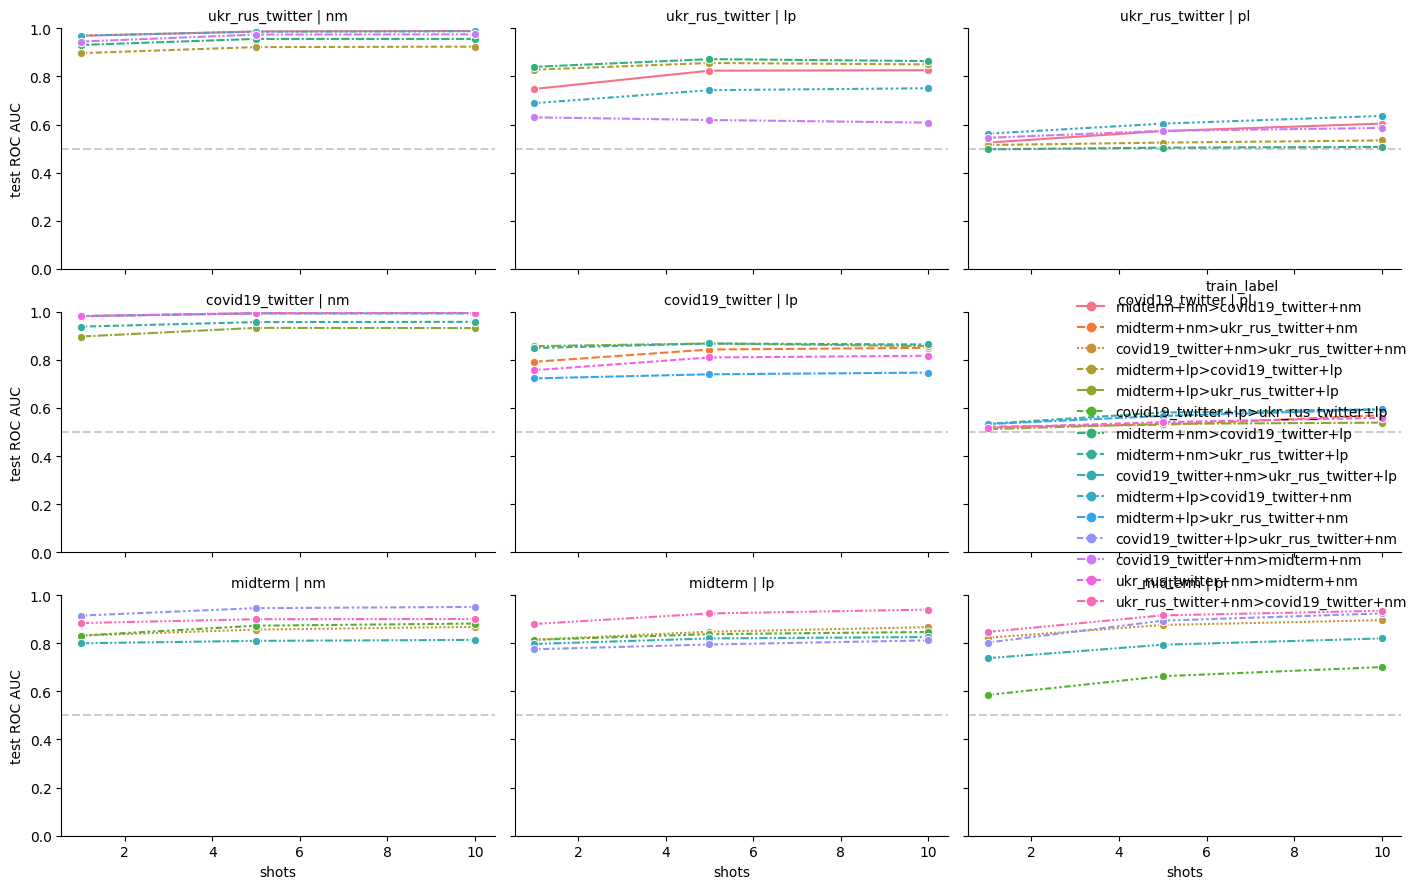

In [1098]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# split eval_id -> dataset/task
# df[["eval_dataset", "eval_task"]] = df["eval_id"].str.rsplit("+", n=1, expand=True)

# df["shots"] = pd.to_numeric(df["shots"])


# optional: make train labels prettier

train2_df["train_label"] = train2_df["train_id"]

g = sns.relplot(
    data=train2_df,
    x="shots",
    y="test_roc_auc",
    hue="train_label",
    style="train_label",
    row="eval_dataset",
    col="eval_task",
    kind="line",
    marker="o",
    estimator=None,   # plot raw values, don't aggregate
    sort=True,
    height=3,
    aspect=1.2,
)

g.set_axis_labels("shots", "test ROC AUC")
g.set_titles(row_template="{row_name}", col_template="{col_name}")

for ax in g.axes.flat:
    ax.axhline(0.5, ls="--", alpha=0.4, color="gray")
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

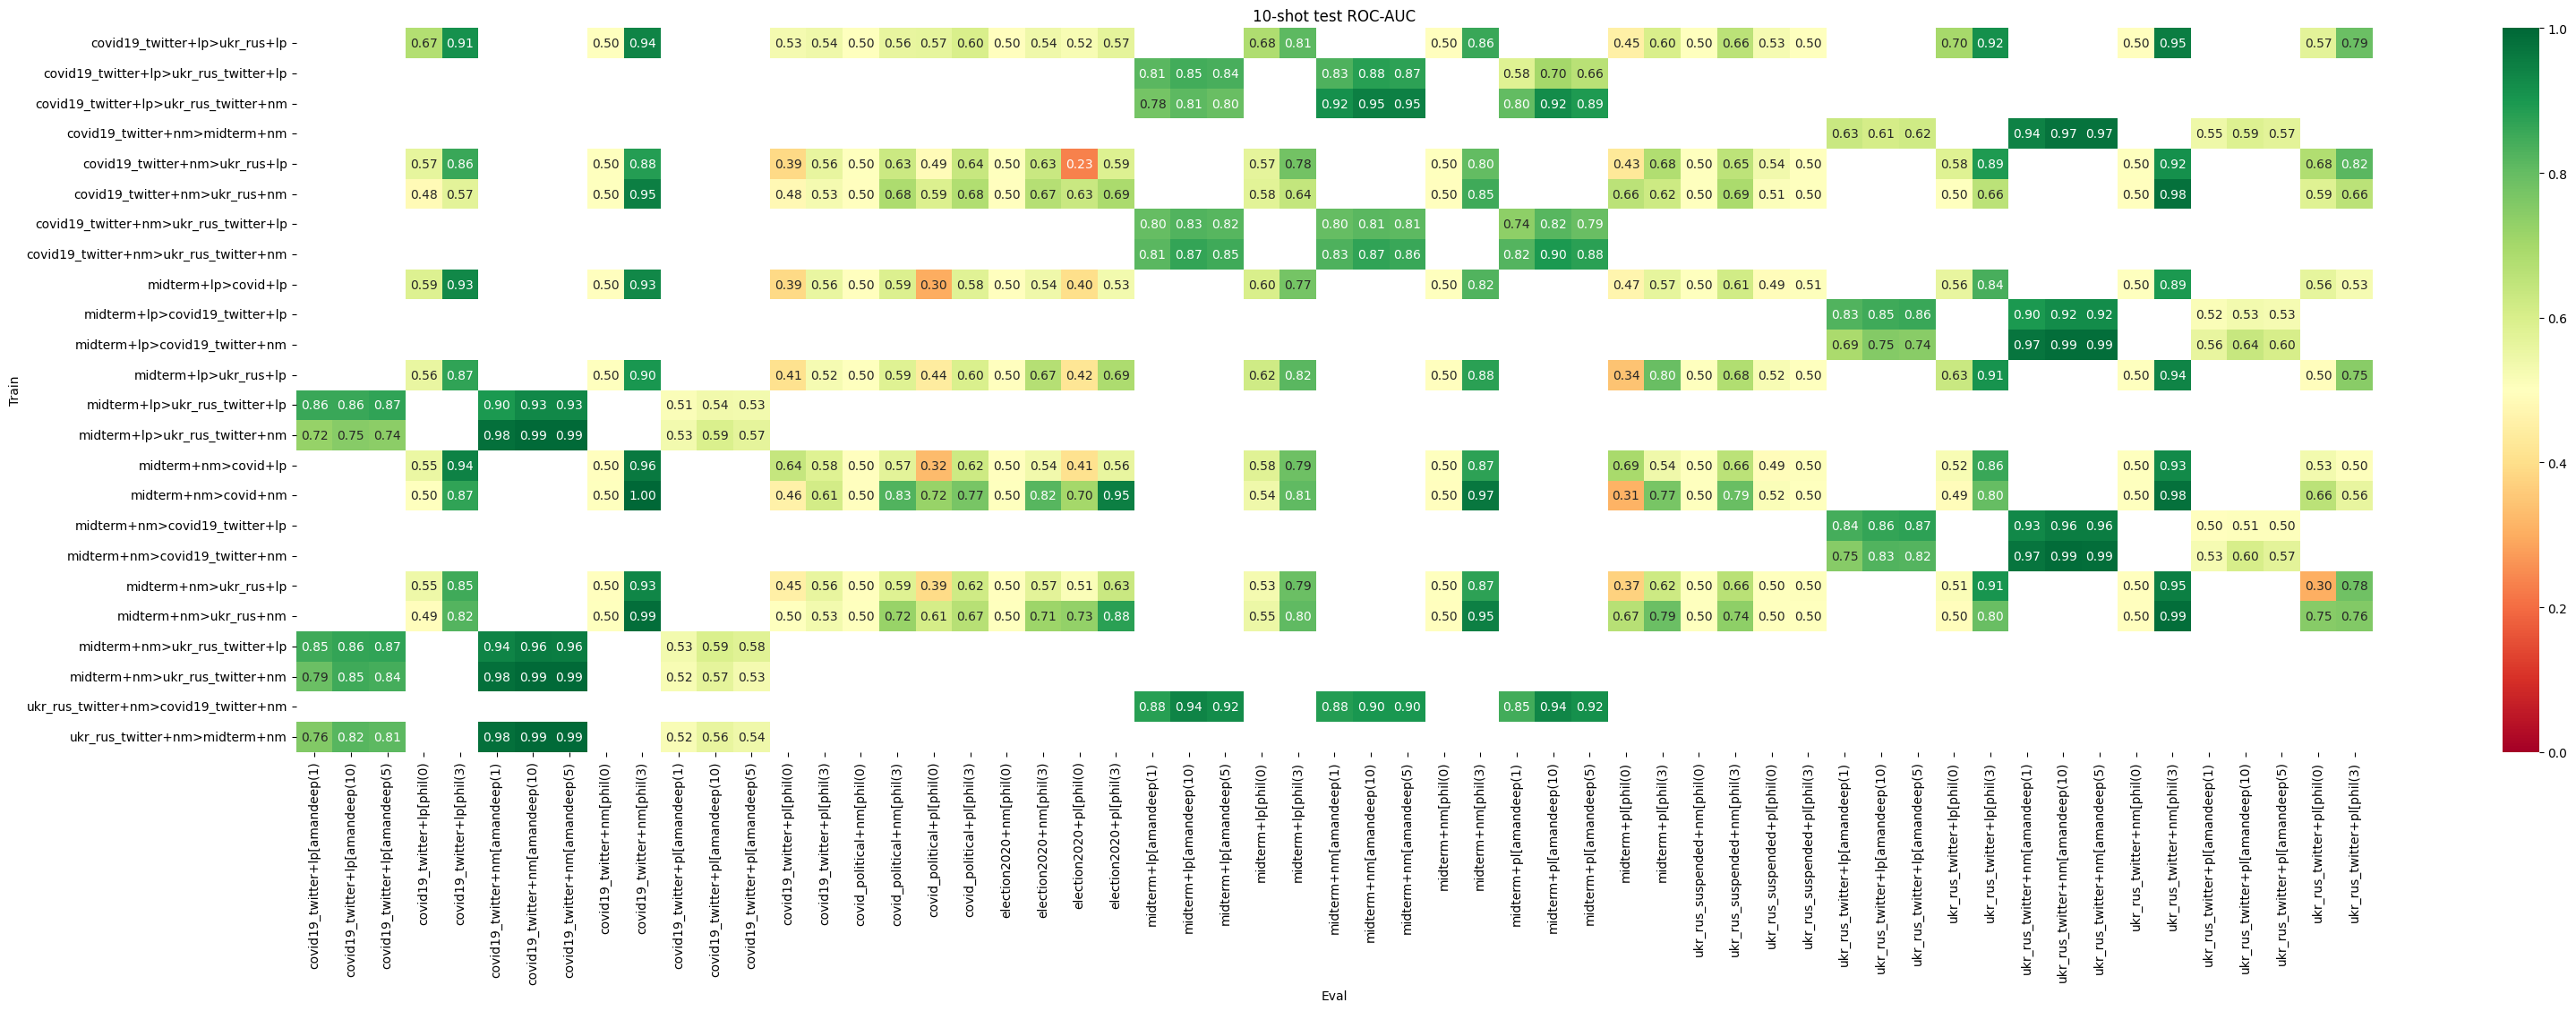

In [1099]:
train2_df['source'] = 'amandeep'
train2_remaining['source'] = 'phil'
train2_merged = pd.merge(train2_df, train2_remaining, how='outer', on=['seq_id', 'test_roc_auc', 
"train_id",
"eval_id",
"seq_id",
"source",
"shots"
])
# [['train_id', 'eval_id', 'test_roc_auc',]]
train2_merged[train2_merged.seq_id.duplicated(keep=False)][['source', 'seq_id', 'test_roc_auc']]
train2_merged['seq_id_'] = train2_merged['seq_id']
train2_merged['eval_id_'] = train2_merged['eval_id'] + "[" + train2_merged.source + "(" + train2_merged.shots.astype(str) + ")"
train2_merged['train_id_'] = train2_merged['train_id']

# train2_merged = train2_merged[train2_merged.shots.isin([3,5])]
train2_merged = train2_merged.sort_values('source')

mat = train2_merged.pivot(
    index="train_id_",
    columns="eval_id_",
    values="test_roc_auc"
)

plt.figure(figsize=(0.5 * mat.shape[1] + 4, 0.35 * mat.shape[0] + 3))
sns.heatmap(mat, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1)
plt.xlabel("Eval")
plt.ylabel("Train")
plt.title("10-shot test ROC-AUC")
plt.tight_layout()
plt.show()


## comparison

In [1100]:
train2_df.groupby('train_id').test_roc_auc.mean().sort_values()

train_id
covid19_twitter+nm>midterm+nm            0.717333
midterm+lp>covid19_twitter+lp            0.761222
midterm+lp>ukr_rus_twitter+nm            0.763556
midterm+nm>covid19_twitter+lp            0.769667
midterm+lp>covid19_twitter+nm            0.769889
midterm+lp>ukr_rus_twitter+lp            0.769889
ukr_rus_twitter+nm>midterm+nm            0.774667
covid19_twitter+lp>ukr_rus_twitter+lp    0.781667
midterm+nm>covid19_twitter+nm            0.782778
midterm+nm>ukr_rus_twitter+nm            0.786444
midterm+nm>ukr_rus_twitter+lp            0.793778
covid19_twitter+nm>ukr_rus_twitter+lp    0.802111
covid19_twitter+nm>ukr_rus_twitter+nm    0.853556
covid19_twitter+lp>ukr_rus_twitter+nm    0.868333
ukr_rus_twitter+nm>covid19_twitter+nm    0.903000
Name: test_roc_auc, dtype: float64

In [1101]:
train2_remaining.groupby('train_id').test_roc_auc.mean().sort_values()

train_id
midterm+lp>covid+lp              0.585617
midterm+nm>ukr_rus+lp            0.598706
midterm+nm>covid+lp              0.606046
covid19_twitter+nm>ukr_rus+lp    0.609624
covid19_twitter+nm>ukr_rus+nm    0.612995
midterm+lp>ukr_rus+lp            0.617661
covid19_twitter+lp>ukr_rus+lp    0.632576
midterm+nm>covid+nm              0.664227
midterm+nm>ukr_rus+nm            0.664819
Name: test_roc_auc, dtype: float64

In [1102]:
train2_merged.groupby('train_id').test_roc_auc.agg(['mean', 'count']).sort_values('mean')

,mean,count
train_id,,
midterm+lp>covid+lp,0.585617,30
midterm+nm>ukr_rus+lp,0.598706,30
midterm+nm>covid+lp,0.606046,30
covid19_twitter+nm>ukr_rus+lp,0.609624,30
covid19_twitter+nm>ukr_rus+nm,0.612995,30
midterm+lp>ukr_rus+lp,0.617661,30
covid19_twitter+lp>ukr_rus+lp,0.632576,30
midterm+nm>covid+nm,0.664227,30
midterm+nm>ukr_rus+nm,0.664819,30


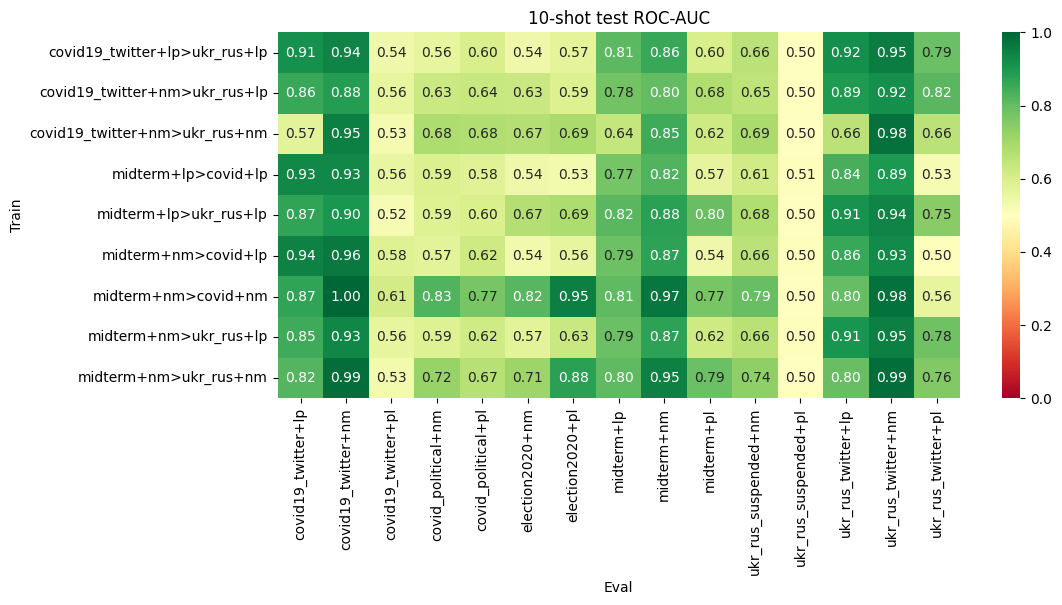

In [1103]:

train2_remaining['seq_id_'] = train2_remaining['seq_id'] + "[" + train2_remaining.source + "](" + train2_remaining.shots.astype(str) + ")"
train2_remaining['eval_id_'] = train2_remaining['eval_id'] + "[" + train2_remaining.source + "](" + train2_remaining.shots.astype(str) + ")"
train2_remaining['train_id_'] = train2_remaining['train_id'] + "[" + train2_remaining.source + "](" + train2_remaining.shots.astype(str) + ")"

mat = train2_remaining[train2_remaining.shots.eq(3)].pivot(
    index="train_id",
    columns="eval_id",
    values="test_roc_auc"
)

plt.figure(figsize=(0.5 * mat.shape[1] + 4, 0.35 * mat.shape[0] + 3))
sns.heatmap(mat, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1)
plt.xlabel("Eval")
plt.ylabel("Train")
plt.title("10-shot test ROC-AUC")
plt.tight_layout()
plt.show()

## plot comparison

In [1104]:
# merge on eval_id
train1['exp_name'] = 'train1'
train2['exp_name'] = 'train2'
df = pd.concat([train1, train2], ignore_index=True)

v0_datasets = ['ukr_rus_twitter', 'midterm', 'covid19_twitter']
df = df[df.eval_dataset.isin(v0_datasets)]

In [1105]:
df[['train_id', 'eval_id', 'n_shots', 'test_roc_auc']]

,train_id,eval_id,n_shots,test_roc_auc
0,NaN,NaN,10.0,0.749280
1,NaN,NaN,10.0,0.567073
2,NaN,NaN,10.0,0.673774
3,NaN,NaN,3.0,0.700935
4,NaN,NaN,3.0,0.576442
...,...,...,...,...
454,ukr_rus_twitter+nm>covid19_twitter+nm,midterm+lp,5.0,0.924000
455,ukr_rus_twitter+nm>covid19_twitter+nm,midterm+lp,10.0,0.940000
456,ukr_rus_twitter+nm>covid19_twitter+nm,midterm+pl,1.0,0.847000
457,ukr_rus_twitter+nm>covid19_twitter+nm,midterm+pl,5.0,0.916000


In [1106]:
# import numpy as np
# df['test_roc_auc'] = df['test_roc_auc'].apply(lambda x: max(x, 1-x))

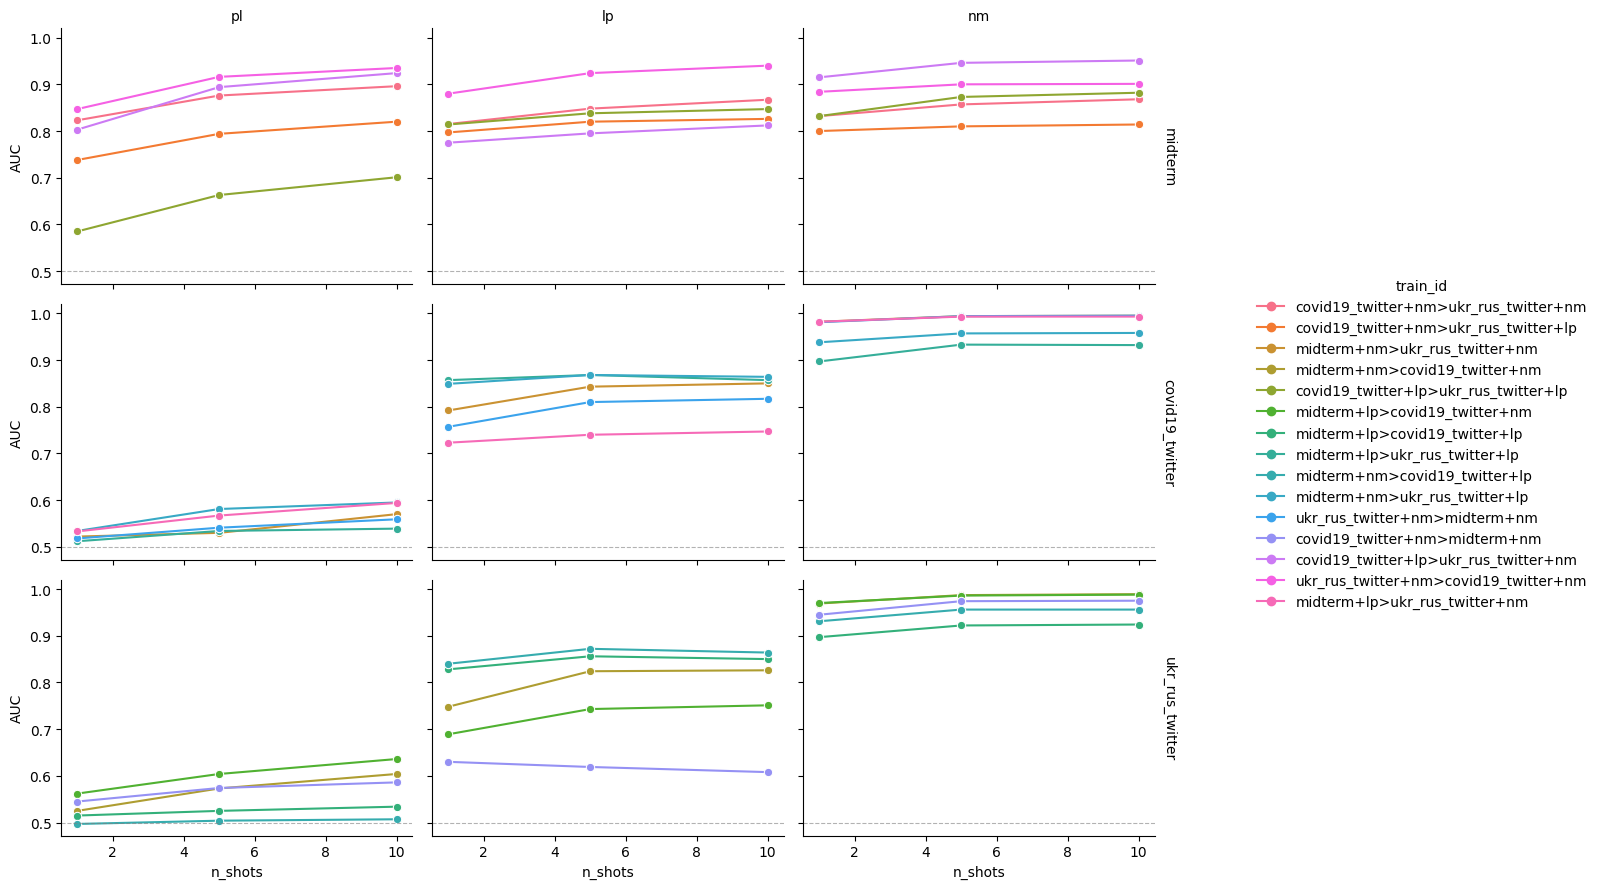

In [1107]:
import seaborn as sns
import matplotlib.pyplot as plt

# split "dataset+task" -> two columns
df[['eval_dataset', 'eval_task']] = df['eval_id'].str.rsplit('+', n=1, expand=True)

g = sns.relplot(
    data=df.sort_values('n_shots'),
    x='n_shots', y='test_roc_auc',
    hue='train_id',
    row='eval_dataset', col='eval_task',
    kind='line', marker='o',
    height=3, aspect=1.4,
    facet_kws={'margin_titles': True},
    errorbar=None,  # drop if you want CIs when there are repeats
)
g.set_axis_labels('n_shots', 'AUC')
g.set_titles(row_template='{row_name}', col_template='{col_name}')
for ax in g.axes.flat:
    ax.axhline(0.5, ls='--', c='gray', lw=0.8, alpha=0.6)  # chance line
g.tight_layout()
plt.show()

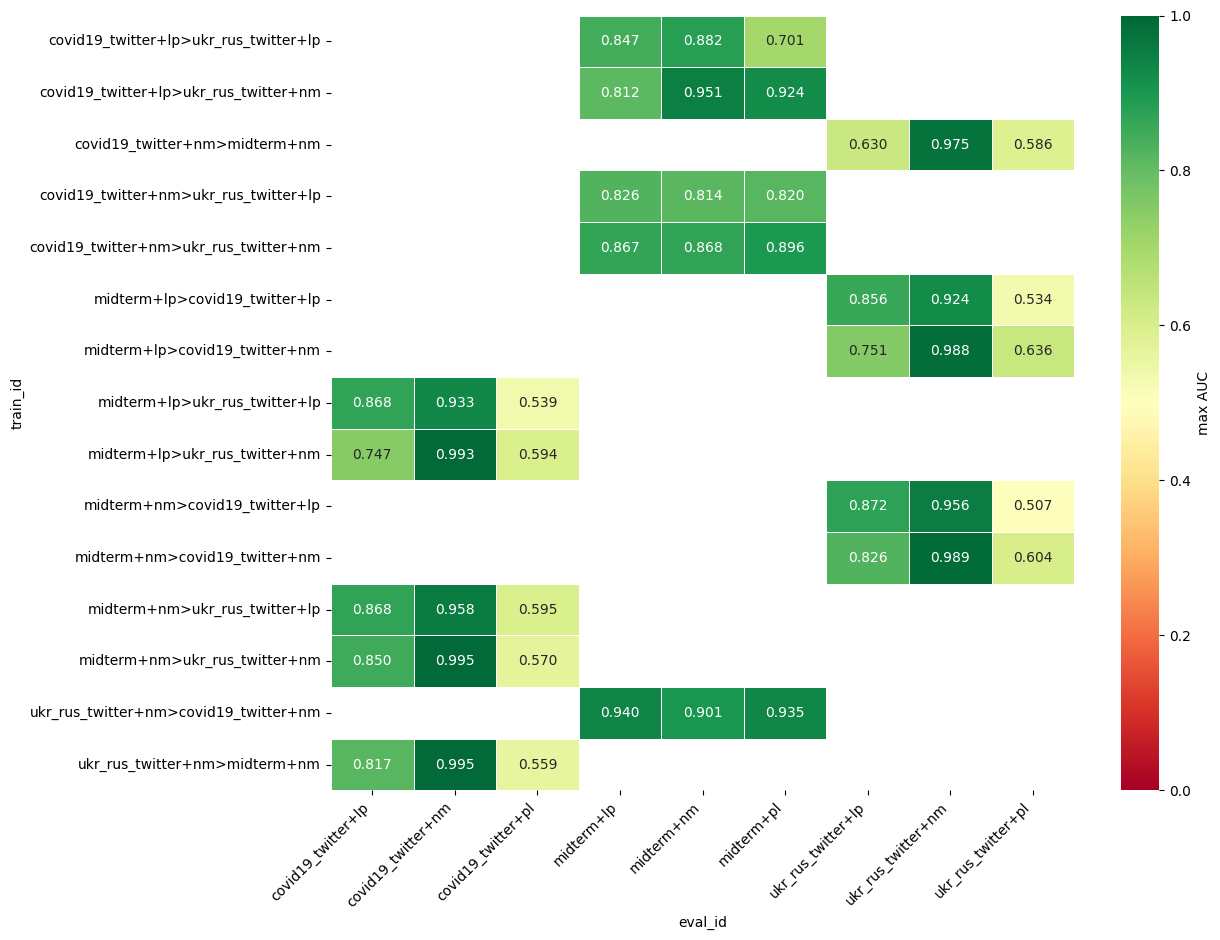

In [1108]:
import seaborn as sns
import matplotlib.pyplot as plt

# TAKING BEST ACROSS SHOTS

# df.groupby('seq_id').test_roc_auc.transform('max')
max_df = df.sort_values('test_roc_auc', ascending=False).drop_duplicates(subset='seq_id')
plot_df = max_df[['train_id', 'eval_id', 'n_shots', 'test_roc_auc']].dropna()

plot_df = plot_df.sort_values('train_id')

# max AUC across n_shots for each (train_id, eval_id)
max_pivot = (plot_df.groupby(['train_id', 'eval_id'])['test_roc_auc']
           .max()
           .unstack('eval_id'))

fig, ax = plt.subplots(figsize=(1.2 * max_pivot.shape[1] + 2, 0.5 * max_pivot.shape[0] + 2))
sns.heatmap(
    max_pivot,
    annot=True, fmt='.3f',
    cmap='RdYlGn', vmin=0., vmax=1.0,  # 0.5 = chance, anchors the colormap meaningfully
    cbar_kws={'label': 'max AUC'},
    linewidths=0.5, linecolor='white',
    ax=ax,
)
ax.set_xlabel('eval_id')
ax.set_ylabel('train_id')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

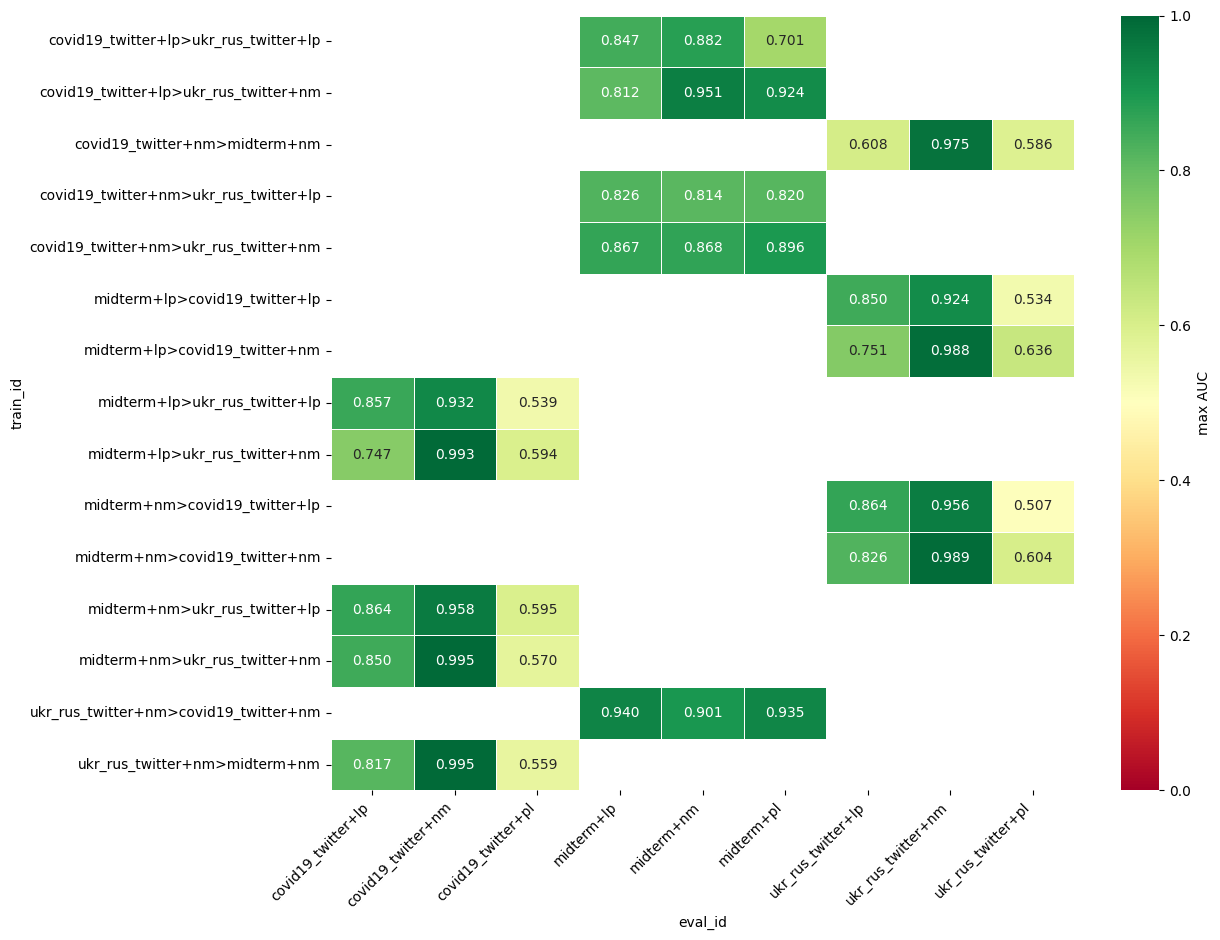

In [1109]:
import seaborn as sns
import matplotlib.pyplot as plt

# TAKING @ 10 SHOTS

# df.groupby('seq_id').test_roc_auc.transform('max')
shot_df = df.sort_values('n_shots', ascending=False).drop_duplicates(subset='seq_id')
plot_df = shot_df[['train_id', 'eval_id', 'n_shots', 'test_roc_auc']].dropna()

plot_df = plot_df.sort_values('train_id')

# max AUC across n_shots for each (train_id, eval_id)
shot_pivot = (plot_df.groupby(['train_id', 'eval_id'])['test_roc_auc']
            .first()
           .unstack('eval_id'))

fig, ax = plt.subplots(figsize=(1.2 * shot_pivot.shape[1] + 2, 0.5 * shot_pivot.shape[0] + 2))
sns.heatmap(
    shot_pivot,
    annot=True, fmt='.3f',
    cmap='RdYlGn', vmin=0., vmax=1.0,  # 0.5 = chance, anchors the colormap meaningfully
    cbar_kws={'label': 'max AUC'},
    linewidths=0.5, linecolor='white',
    ax=ax,
)
ax.set_xlabel('eval_id')
ax.set_ylabel('train_id')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

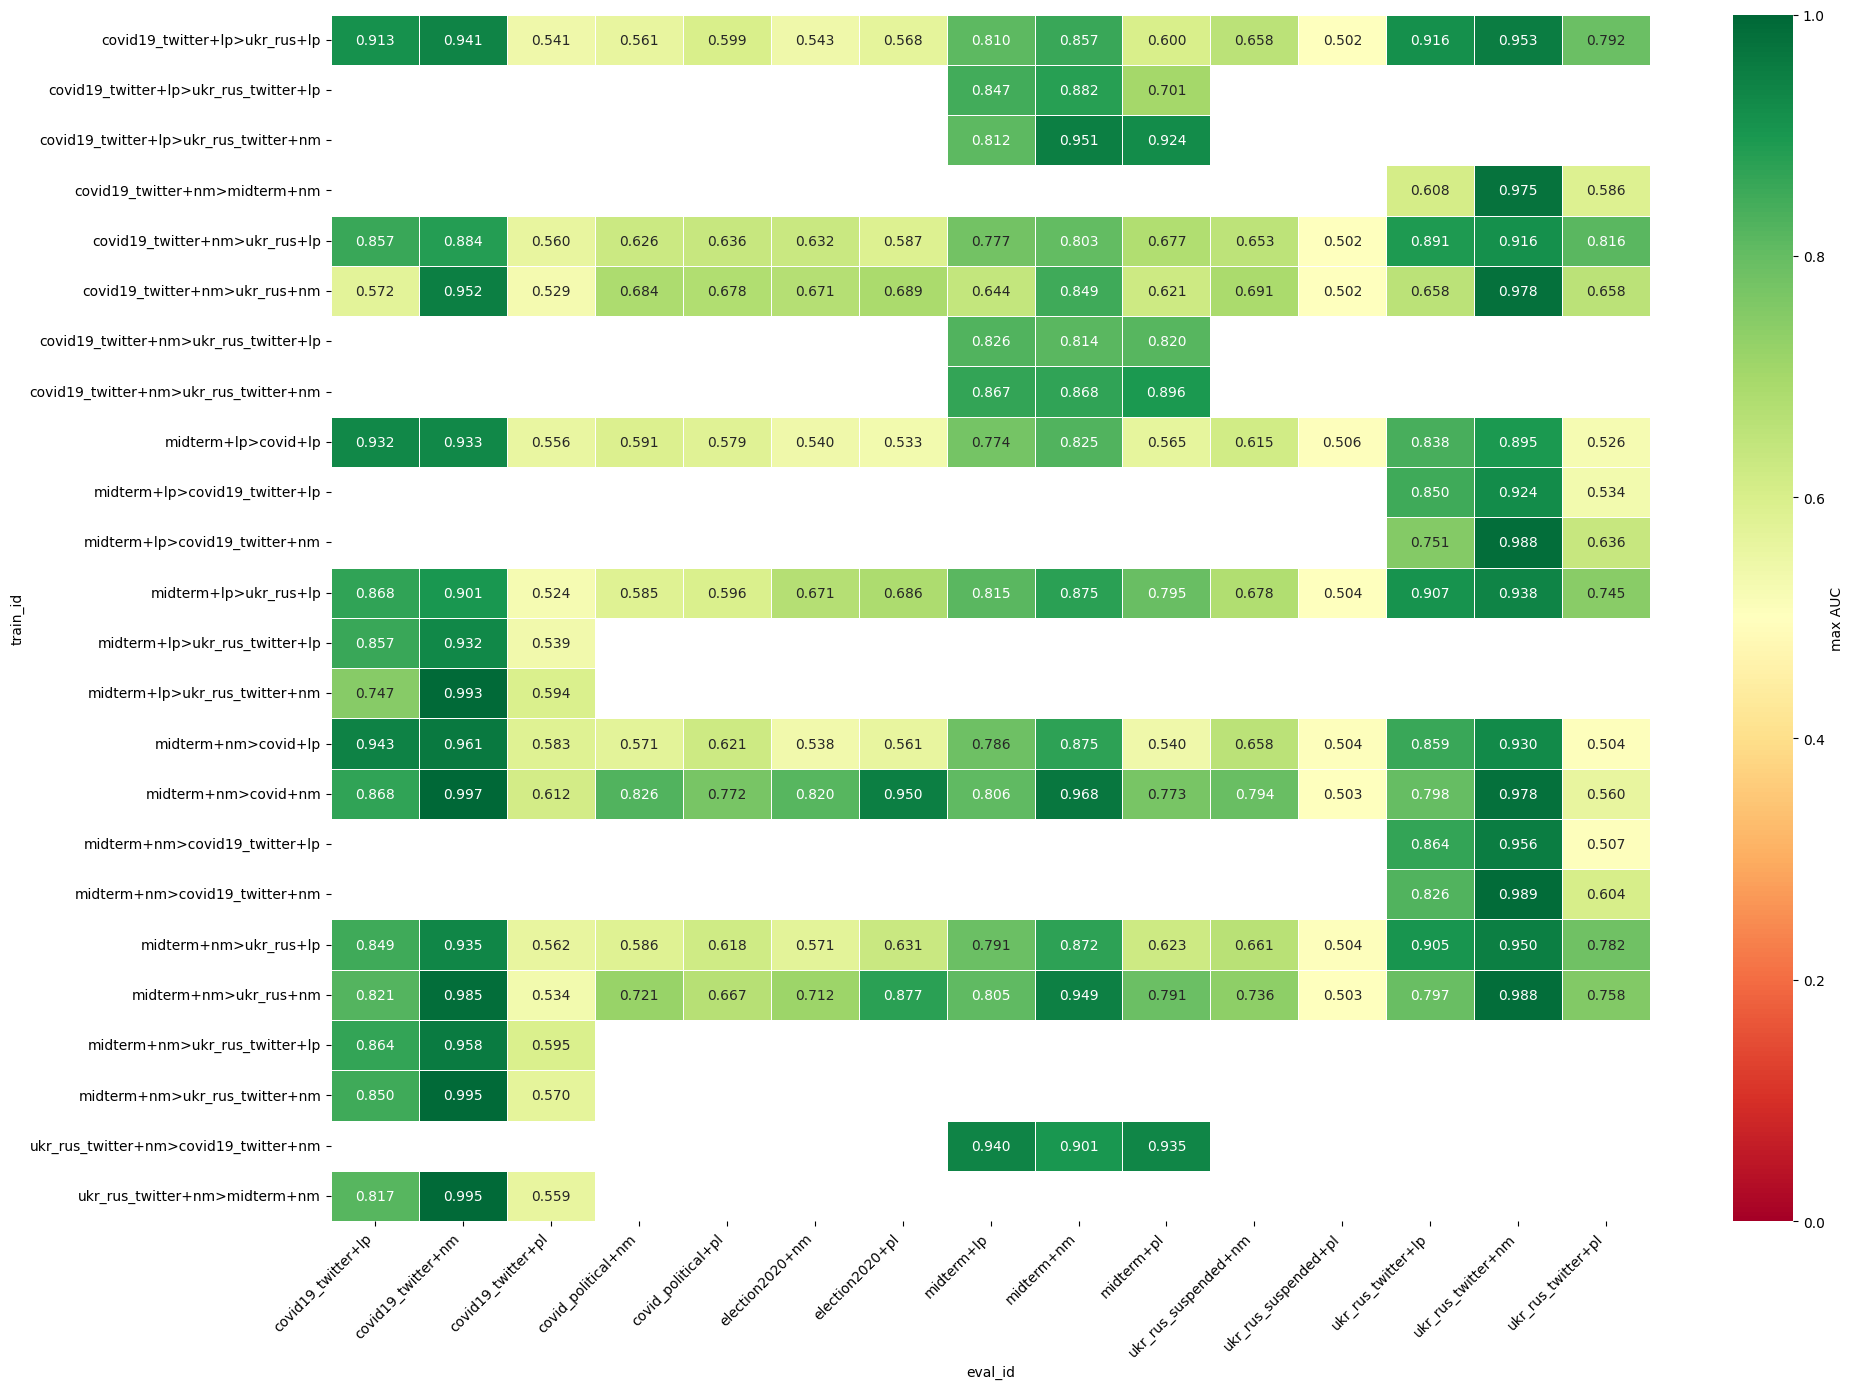

In [1124]:
import seaborn as sns
import matplotlib.pyplot as plt

# TAKING @ 10 SHOTS

# df.groupby('seq_id').test_roc_auc.transform('max')
shot_df = train2_merged.sort_values('shots', ascending=False).drop_duplicates(subset='seq_id')
plot_df = shot_df[['train_id', 'eval_id', 'shots', 'test_roc_auc']].dropna()

plot_df = plot_df.sort_values('train_id')

# max AUC across n_shots for each (train_id, eval_id)
shot_pivot = (plot_df.groupby(['train_id', 'eval_id'])['test_roc_auc']
            .first()
           .unstack('eval_id'))

fig, ax = plt.subplots(figsize=(1.2 * shot_pivot.shape[1] + 2, 0.5 * shot_pivot.shape[0] + 2))
sns.heatmap(
    shot_pivot,
    annot=True, fmt='.3f',
    cmap='RdYlGn', vmin=0., vmax=1.0,  # 0.5 = chance, anchors the colormap meaningfully
    cbar_kws={'label': 'max AUC'},
    linewidths=0.5, linecolor='white',
    ax=ax,
)
ax.set_xlabel('eval_id')
ax.set_ylabel('train_id')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [1197]:
# df[(
#     df.display_name.str.contains('covid_political')
#     & df.display_name.str.contains('ukr_rus_twitter')
#     )][['display_name', 'pretrained_model_run', 'dataset', 'task_name']].sample(3).values

datasets_pat = "ukr_rus_twitter|covid19_twitter|covid_political|midterm|election2020|ukr_rus_suspended"
pat = f'eval_({datasets_pat})_(nm|lp|pl)_to_({datasets_pat})_(nm|pl|lp)_(..?)shot'
cols = ['train1_dataset', 'train1_task', 'eval_dataset', 'eval_task', 'shots']
fd = df[df.display_name.str.contains(pat, regex=True)].copy()
fd[cols] = df.display_name.str.extract(pat)
# fd = fd[fd.train1_dataset.notna()]
unique_on = ['train1_dataset', 'train1_task', 'eval_dataset', 'eval_task', 'shots']
fd = fd.dropna(subset='test_roc_auc')
fd['auc_rounded'] = fd.test_roc_auc.round(1)
fd = fd.drop_duplicates(unique_on + ['auc_rounded'])
# fd[['display_name', 'pretrained_model_run']]

# fd['seq_id'] = fd.train1_dataset +'+'+ fd.train1_task +'|'+ fd.eval_dataset +'+'+ fd.eval_task

/var/folders/6w/cs8z0j913k1d_x_ywtvrm5xc0000gp/T/ipykernel_62767/587794024.py:9: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  fd = df[df.display_name.str.contains(pat, regex=True)].copy()


In [1198]:
# fd[fd.display_name.eq('eval_midterm_pl_to_election2020_nm_10shot_23_04_2026_01_00_39')]
d = fd.copy()

d['train1_tuple'] = d.train1_dataset + "+" + d.train1_task
d['train_id'] = d['train1_tuple']
d['eval_tuple'] = d.eval_dataset + "+" + d.eval_task
d['eval_id'] = d.eval_tuple
d['seq_id'] = d.train_id + "|" + d.eval_id
d[d.display_name.eq('eval_midterm_pl_to_election2020_nm_10shot_23_04_2026_01_00_39')]

,run_id,display_name,state,dataset,task_name,prefix,pretrained_model_run,n_shots,n_way,n_query,...,train1_task,eval_dataset,eval_task,shots,auc_rounded,train1_tuple,train_id,eval_tuple,eval_id,seq_id
432,vz473dc6,eval_midterm_pl_to_election2020_nm_10shot_23_0...,finished,election2020,nm,eval_midterm_pl_to_election2020_nm_10shot,state/train1_midterm_pl_1p5m_13_04_2026_17_14_...,10.0,3.0,12.0,...,pl,election2020,nm,10,0.6,midterm+pl,midterm+pl,election2020+nm,election2020+nm,midterm+pl|election2020+nm


In [1200]:
train2_remaining.display_name.str[:20].value_counts()

display_name
eval_exp9_covid_nm_t    30
eval_exp8_midterm_nm    30
eval_exp7_midterm_nm    30
eval_exp6_covid_lp_t    30
eval_exp5_midterm_lp    30
eval_exp4_midterm_lp    30
eval_exp3_covid_nm_t    30
eval_exp2_midterm_nm    30
eval_exp1_midterm_nm    30
Name: count, dtype: int64

In [ ]:
fd['train1_tuple'] = fd.train1_dataset + "+" + fd.train1_task
fd['train_id'] = fd['train1_tuple']
fd['eval_tuple'] = fd.eval_dataset + "+" + fd.eval_task
fd['eval_id'] = fd.eval_tuple
fd['seq_id'] = fd.train_id + "|" + fd.eval_id
fd['s_'] = 'd'

pseudo_data = fd[fd.shots.astype(int).isin([1,10])].set_index('seq_id')[['shots', 'test_roc_auc']].groupby(level=0).test_roc_auc.mean()
r = fd[fd.shots.astype(int).eq(3)].set_index('seq_id')
pseudo_data = pseudo_data[~pseudo_data.index.isin(r.index)].to_frame()
pseudo_data['shots'] = 5
d = pd.concat([r, pseudo_data])

In [1446]:
a = train1[train1.n_shots.eq(3)]
a['shots'] = 3
a[['train1_dataset', 'train1_task']] = a['pretrained_model_run'].str.extractall(r'state/train1_(midterm|covid19_twitter|ukr_rus_twitter)_(nm|lp|pl)_.+').values
a['train1_tuple'] = a.train1_dataset + "+" + a.train1_task
a['train_id'] = a['train1_tuple']
a[['eval_dataset', 'eval_task']] = a[['dataset', 'task_name']]
a['eval_tuple'] = a.eval_dataset + "+" + a.eval_task 
a['eval_id'] = a.eval_tuple
a['seq_id'] = a.train_id + "|" + a.eval_id
a['s_'] = 'a'
# b.eval_id.isna().sum()

b = train2[train2.shots.eq(5)]
b['train1_tuple'] = b.train1_dataset + "+" + b.train1_task
b['train2_tuple'] = b.train2_dataset + "+" + b.train2_task
b['train_id'] = b['train1_tuple'] + ">" + b['train2_tuple']
b['eval_tuple'] = b.eval_dataset + "+" + b.eval_task
b['eval_id'] = b.eval_tuple
b['seq_id'] = b.train_id + "|" + b.eval_id
b['s_'] = 'b'

c = train2_remaining[train2_remaining.shots.eq(3)]
c['s_'] = 'c'

pseudo_data = fd[fd.shots.astype(int).isin([1,10])].set_index('seq_id')[['shots', 'test_roc_auc']].groupby(level=0).test_roc_auc.mean()
r = fd[fd.shots.astype(int).eq(3)].set_index('seq_id')
pseudo_data = pseudo_data[~pseudo_data.index.isin(r.index)].to_frame()
pseudo_data['shots'] = 5
d = pd.concat([r, pseudo_data])
d = d.reset_index()
# d['train1_tuple'] = d.train1_dataset + "+" + d.train1_task
# d['train_id'] = d['train1_tuple']
# d['eval_tuple'] = d.eval_dataset + "+" + d.eval_task
# d['eval_id'] = d.eval_tuple
# d['seq_id'] = d.train_id + "|" + d.eval_id
d['s_'] = 'd'

joined = pd.concat([
    a,
    # b,
    c,
    d
    ],axis=0, join='outer')

joined['auc_rounded'] = joined.test_roc_auc.round(3)
joined = joined.drop_duplicates(['seq_id', 'auc_rounded'], keep='first')


# split train side vs eval side
joined[['train_id', 'eval_tuple']] = joined['seq_id'].str.extract(r'^(.+)\|(.+)$')
joined['eval_id'] = joined.eval_tuple

# split train chain into train1 / optional train2
joined[['train1_tuple', 'train2_tuple']] = joined['train_id'].str.extract(r'^([^>]+)(?:>([^>]+))?$')

# split tuple = dataset+task
joined[['train1_dataset', 'train1_task']] = joined['train1_tuple'].str.extract(r'^(.+)\+(nm|pl|lp)$')
joined[['eval_dataset', 'eval_task']] = joined['eval_tuple'].str.extract(r'^(.+)\+(nm|pl|lp)$')

# only split train2 where it exists
joined[['train2_dataset', 'train2_task']] = joined['train2_tuple'].str.extract(r'^(.+)\+(nm|pl|lp)$')

In [1449]:
# joined[joined.seq_id.eq('midterm+lp|covid_political+nm')]

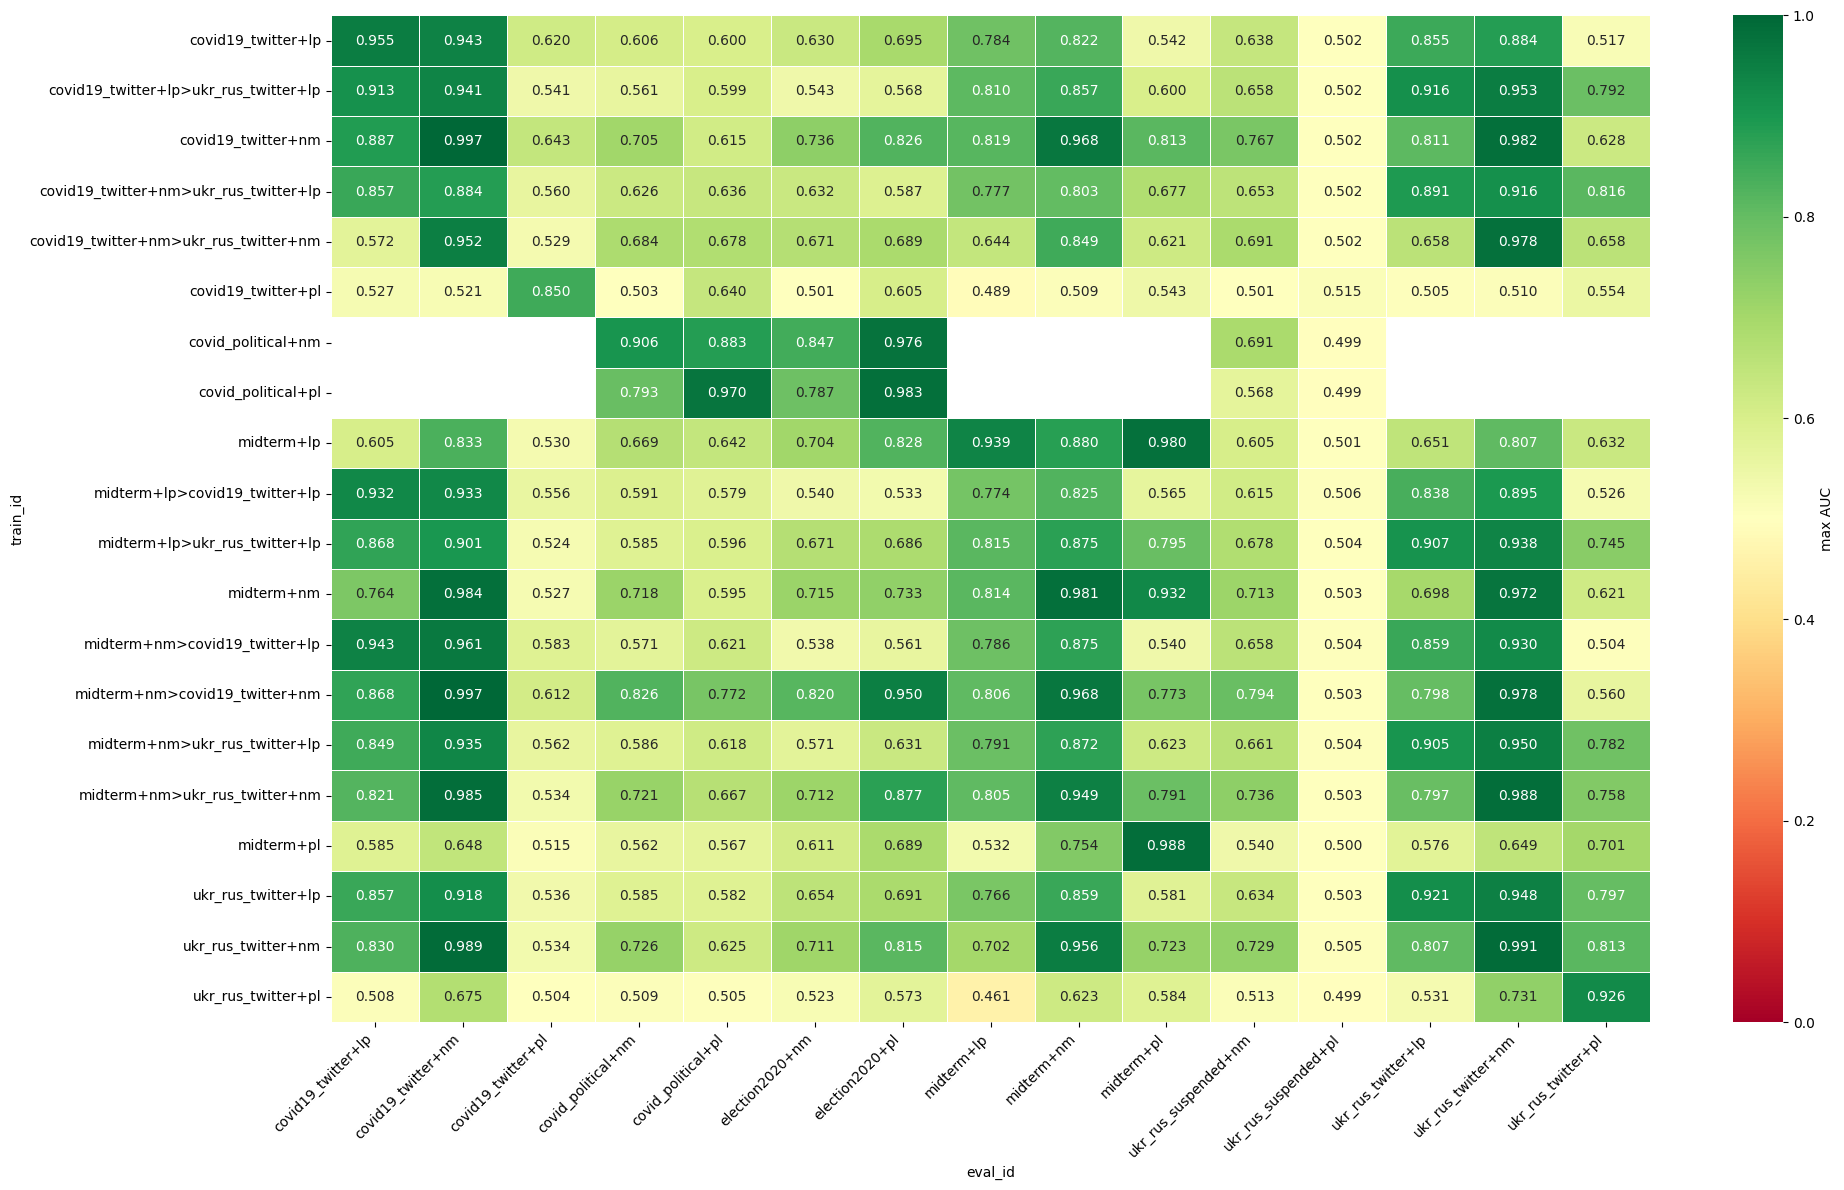

In [1450]:

mat = (joined.groupby(['train_id', 'eval_id'])['test_roc_auc']
            .first()
           .unstack('eval_id'))

fig, ax = plt.subplots(figsize=(1.2 * mat.shape[1] + 2, 0.5 * mat.shape[0] + 2))
sns.heatmap(
    mat,
    annot=True, fmt='.3f',
    cmap='RdYlGn', vmin=0., vmax=1.0,  # 0.5 = chance, anchors the colormap meaningfully
    cbar_kws={'label': 'max AUC'},
    linewidths=0.5, linecolor='white',
    ax=ax,
)
ax.set_xlabel('eval_id')
ax.set_ylabel('train_id')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## again yay

In [1453]:
joined['train2_tuple'] = joined.train2_dataset + "+" + joined.train2_task
joined['exp_name'] = joined.seq_id.str.contains('>').map({True: 'train2', False: 'train1'})
# joined['shots'] = pd.to_numeric(joined.n_shots).astype(int)
joined['train1_tuple'] = joined.train1_dataset + "+" + joined.train1_task
joined['eval_tuple'] = joined.eval_dataset + "+" + joined.eval_task
tdf = joined.copy()
tdf = tdf.drop_duplicates('seq_id')

## does order matter?

In [1454]:
order_df = []
# does order matter
for i, row in tdf[tdf.exp_name.eq('train2')].iterrows():
    T1 = row.train1_tuple
    T2 = row.train2_tuple
    E = row.eval_tuple
    mask = (
        tdf.train1_tuple.eq(T2) &
        tdf.train2_tuple.eq(T1) &
        tdf.eval_tuple.eq(E) 
    )
    if tdf[mask].shape[0] == 1:
        delta = tdf.loc[i].test_roc_auc - tdf[mask].iloc[0].test_roc_auc
        s = pd.Series({"Train1": T1, "Train2": T2, "Eval": E, 'A>B - B>A': delta, "Both": frozenset([T1, T2]), "delta": delta})
        order_df.append(s)
    elif tdf[mask].shape[0] > 1:
        raise ValueError('more than one match')
        
        
order_df = None
try:
    order_df = pd.DataFrame(order_df)
    order_df.sort_values(["Eval", 'Train1']).drop_duplicates(['Both', 'Eval'])[['Train1', 'Train2', 'Eval', 'delta']]
except:
    print('idk')


idk


# impact of a new dataset

### impact of a second dataset on the same dataset and task


**Control:**

D1T1 | D1T1

**Treatment:**

D1T1 > D2T1

D2T1 > D1T1

In [1455]:
dfs = []
for i, row in tdf[tdf.exp_name.eq('train1')].iterrows():
    tf = tdf.copy()
    
    if row.train1_tuple != row.eval_tuple:
        continue
    mask = (
        tf.exp_name.eq('train2') &
        (tf.train1_tuple.eq(row.train1_tuple) & tf.train2_task.eq(row.train1_task) & tf.eval_tuple.eq(row.eval_tuple)) |
        (tf.train2_tuple.eq(row.train1_tuple) & tf.train1_task.eq(row.train1_task) & tf.eval_tuple.eq(row.eval_tuple))
    )
    if tf[mask].shape[0] > 0:
        # display(tdf[mask])
        deltas = (tf[mask].test_roc_auc - row.test_roc_auc)
        tf.loc[mask, 'delta'] = deltas
        tf.loc[mask, 'compared_to'] = row.seq_id
        tf.loc[mask, 'added'] = tf.loc[mask, 'train2_tuple']
        dfs.append(tf[mask])
        # print(row.seq_id)
        # print(deltas)
        # print()
        # means.append(deltas.mean())

pd.concat(dfs)[['seq_id', 'compared_to', 'delta']]
# pd.concat(dfs)[['compared_to', 'added', 'seq_id', 'delta']].sort_values('added')

,seq_id,compared_to,delta
127,midterm+lp>ukr_rus_twitter+lp|midterm+lp,midterm+lp|midterm+lp,-0.123380
155,midterm+lp>covid19_twitter+lp|midterm+lp,midterm+lp|midterm+lp,-0.164301
132,covid19_twitter+lp>ukr_rus_twitter+lp|covid19_...,covid19_twitter+lp|covid19_twitter+lp,-0.041625
180,midterm+lp>covid19_twitter+lp|covid19_twitter+lp,covid19_twitter+lp|covid19_twitter+lp,-0.022811
52,covid19_twitter+lp>ukr_rus_twitter+lp|ukr_rus_...,ukr_rus_twitter+lp|ukr_rus_twitter+lp,-0.004651
84,midterm+lp>ukr_rus_twitter+lp|ukr_rus_twitter+lp,ukr_rus_twitter+lp|ukr_rus_twitter+lp,-0.013644
210,covid19_twitter+nm>ukr_rus_twitter+nm|covid19_...,covid19_twitter+nm|covid19_twitter+nm,-0.044731
257,midterm+nm>covid19_twitter+nm|covid19_twitter+nm,covid19_twitter+nm|covid19_twitter+nm,0.000197
174,covid19_twitter+nm>ukr_rus_twitter+nm|ukr_rus_...,ukr_rus_twitter+nm|ukr_rus_twitter+nm,-0.012889
211,midterm+nm>ukr_rus_twitter+nm|ukr_rus_twitter+nm,ukr_rus_twitter+nm|ukr_rus_twitter+nm,-0.002949


### impact of a second dataset on the same dataset, new task


**Control:**

D1T1 | D1T2

**Treatment:**

D1T1 > D2T1

D2T1 > D1T1

In [1212]:
dfs = []
for i, row in tdf[tdf.exp_name.eq('train1')].iterrows():
    if row.train1_tuple != row.eval_tuple:
        continue
    mask = (
        tdf.exp_name.eq('train2') &
        (tdf.train1_tuple.eq(row.train1_tuple) & tdf.train2_task.eq(row.train1_task) & tdf.eval_tuple.eq(row.eval_tuple)) |
        (tdf.train2_tuple.eq(row.train1_tuple) & tdf.train1_task.eq(row.train1_task) & tdf.eval_tuple.eq(row.eval_tuple))
    )
    if tdf[mask].shape[0] > 0:
        # display(tdf[mask])
        deltas = (tdf[mask].test_roc_auc - row.test_roc_auc)
        tdf.loc[mask, 'delta'] = deltas
        tdf.loc[mask, 'compared_to'] = row.seq_id
        tdf.loc[mask, 'added'] = tdf.loc[mask, 'train2_tuple']
        dfs.append(tdf[mask])
        # print(row.seq_id)
        # print(deltas)
        # print() 
        # means.append(deltas.mean())
print(pd.concat(dfs)[['seq_id', 'compared_to', 'delta']].delta.mean())
# pd.concat(dfs)[['compared_to', 'added', 'seq_id', 'delta']].sort_values('added')

-0.06989177028163579


### impact of a second dataset on the same task, new dataset


**Control:**

D1T1 | D2T1

**Treatment:**

D1T1 > D3T1

D3T1 > D1T1

...*where 3 != 2*

In [1134]:
dfs = []
for i, row in tdf[tdf.exp_name.eq('train1')].iterrows():
    if row.train1_tuple != row.eval_tuple:
        continue
    mask = (
        tdf.exp_name.eq('train2') &
        (tdf.train1_tuple.eq(row.train1_tuple) & tdf.train2_task.eq(row.train1_task) & tdf.eval_tuple.eq(row.eval_tuple)) |
        (tdf.train2_tuple.eq(row.train1_tuple) & tdf.train1_task.eq(row.train1_task) & tdf.eval_tuple.eq(row.eval_tuple))
    )
    if tdf[mask].shape[0] > 0:
        # display(tdf[mask])
        deltas = (tdf[mask].test_roc_auc - row.test_roc_auc)
        tdf.loc[mask, 'delta'] = deltas
        tdf.loc[mask, 'compared_to'] = row.seq_id
        tdf.loc[mask, 'added'] = tdf['train2_tuple']
        dfs.append(tdf[mask])
        # print(row.seq_id)
        # print(deltas)
        # print() 
        # means.append(deltas.mean())
# print(pd.concat(dfs)[['seq_id', 'compared_to', 'delta']].delta.mean())
# pd.concat(dfs)[['compared_to', 'added', 'seq_id', 'delta']].sort_values('added')

#### what if D2 = D3



**Control:**

D1T1 | D2T1

**Treatment:**

D1T1 > D2T1

D2T1 > D1T1

...*where 3 == 2*

In [1135]:
dfs = []
for i, row in tdf[tdf.exp_name.eq('train1')].iterrows():
    if row.train1_tuple != row.eval_tuple:
        continue
    mask = (
        tdf.exp_name.eq('train2') &
        (tdf.train1_tuple.eq(row.train1_tuple) & tdf.train2_task.eq(row.train1_task) & tdf.eval_tuple.eq(row.eval_tuple)) |
        (tdf.train2_tuple.eq(row.train1_tuple) & tdf.train1_task.eq(row.train1_task) & tdf.eval_tuple.eq(row.eval_tuple))
    )
    if tdf[mask].shape[0] > 0:
        # display(tdf[mask])
        deltas = (tdf[mask].test_roc_auc - row.test_roc_auc)
        tdf.loc[mask, 'delta'] = deltas
        tdf.loc[mask, 'compared_to'] = row.seq_id
        tdf.loc[mask, 'added'] = tdf['train2_tuple']
        dfs.append(tdf[mask])
        # print(row.seq_id)
        # print(deltas)
        # print() 
        # means.append(deltas.mean())
# pd.Series(means).mean()

# print(pd.concat(dfs)[['seq_id', 'compared_to', 'delta']].delta.mean())
# pd.concat(dfs)[['compared_to', 'added', 'seq_id', 'delta']].sort_values('added')

### impact of a second dataset on the same task, new dataset

**Control:**

D1T1 | D2T1

**Treatment:**

D1T1 > D3T1

D3T1 > D1T1

...*where 3 != 2*

In [1136]:
dfs = []
for i, row in tdf[tdf.exp_name.eq('train1')].iterrows():
    if row.train1_tuple != row.eval_tuple:
        continue
    mask = (
        tdf.exp_name.eq('train2') &
        (tdf.train1_tuple.eq(row.train1_tuple) & tdf.train2_task.eq(row.train1_task) & tdf.eval_tuple.eq(row.eval_tuple)) |
        (tdf.train2_tuple.eq(row.train1_tuple) & tdf.train1_task.eq(row.train1_task) & tdf.eval_tuple.eq(row.eval_tuple))
    )
    if tdf[mask].shape[0] > 0:
        # display(tdf[mask])
        deltas = (tdf[mask].test_roc_auc - row.test_roc_auc)
        tdf.loc[mask, 'delta'] = deltas
        tdf.loc[mask, 'compared_to'] = row.seq_id
        tdf.loc[mask, 'added'] = tdf['train2_tuple']
        dfs.append(tdf[mask])
        # print(row.seq_id)
        # print(deltas)
        # print() 
        # means.append(deltas.mean())
# pd.Series(means).mean()
len(dfs)
# print(pd.concat(dfs)[['seq_id', 'compared_to', 'delta']].delta.mean())
# pd.concat(dfs)[['compared_to', 'added', 'seq_id', 'delta']].sort_values('added')

4

# impact of a new task

**Control:**

D1T1 | D1T1

**Treatment:**

D1T1 > D1T2

D1T2 > D1T1

idk

impact of a new dataset on the same dataset+task

treatment: DiTj + DkTj

control: DiTj

Y: DiTj

In [1145]:
# tdf[tdf.display_name.str.contains('eval_covid_political_pl_to_covid_political_pl_1shot_23_04_2026_01_34_57')].seq_id

# tdf[tdf.train1_dataset.isna()]
# joined.display_name.str.startswith('train1_covid19_twitter_nm_interacti').sum()

In [1464]:

def auc_for(seq_id):
    match = tdf.loc[tdf.seq_id.eq(seq_id), "test_roc_auc"]
    if len(match) > 1:
        raise ValueError(f"Expected 1 row for {seq_id}, got {len(match)}")
    if len(match) == 0:
        print("[WARN] 0 entries for:", {seq_id})
    else:
        return match.iloc[0]

In [1465]:
rows = []
datasets = set(tdf.train1_dataset.unique().tolist() + tdf.train2_dataset.dropna().unique().tolist() + tdf.eval_dataset.unique().tolist())
tasks = set(tdf.train1_task.unique().tolist() + tdf.train2_task.dropna().unique().tolist() + tdf.eval_task.unique().tolist())

for Di in datasets:
    for Tj in tasks:
        DiTj = f"{Di}+{Tj}"

        control_id = f"{DiTj}|{DiTj}"
        control_auc = auc_for(control_id)

        for Dk in datasets:
            if Dk == Di:
                continue

            DkTj = f"{Dk}+{Tj}"

            treatment_ids = [
                f"{DiTj}>{DkTj}|{DiTj}",
                f"{DkTj}>{DiTj}|{DiTj}",
            ]

            for treatment_id in treatment_ids:
                treatment_auc = tdf.loc[
                    tdf.seq_id.eq(treatment_id), "test_roc_auc"
                ]

                if not treatment_auc.empty:
                    rows.append({
                        "control": control_id,
                        "treatment": treatment_id,
                        "delta": treatment_auc.mean() - control_auc,
                        "y": DiTj,
                    })

DiTj = pd.DataFrame(rows)
DiTj.delta.mean()

[WARN] 0 entries for: {'election2020+lp|election2020+lp'}
[WARN] 0 entries for: {'election2020+pl|election2020+pl'}
[WARN] 0 entries for: {'election2020+nm|election2020+nm'}
[WARN] 0 entries for: {'covid_political+lp|covid_political+lp'}
[WARN] 0 entries for: {'ukr_rus_suspended+lp|ukr_rus_suspended+lp'}
[WARN] 0 entries for: {'ukr_rus_suspended+pl|ukr_rus_suspended+pl'}
[WARN] 0 entries for: {'ukr_rus_suspended+nm|ukr_rus_suspended+nm'}


-0.03967472374807097

impact of a new task on the same dataset, new task

treatment: DiTj + DkTj

control: DiTj

Y: DiTn

In [1466]:
rows = []
datasets = tdf.train1_dataset.unique()
tasks = tdf.train1_task.unique()

for Di in datasets:
    for Tj in tasks:
        DiTj = f"{Di}+{Tj}"

        for Tn in tasks:
            if Tn == Tj:
                continue

            DiTn = f"{Di}+{Tn}"
            control_id = f"{DiTj}|{DiTn}"
            control_auc = auc_for(control_id)

            for Dk in datasets:
                if Dk == Di:
                    continue

                DkTj = f"{Dk}+{Tj}"

                treatment_ids = [
                    f"{DiTj}>{DkTj}|{DiTn}",
                    f"{DkTj}>{DiTj}|{DiTn}",
                ]

                for treatment_id in treatment_ids:
                    treatment_auc = tdf.loc[
                        tdf.seq_id.eq(treatment_id), "test_roc_auc"
                    ]

                    if not treatment_auc.empty:
                        rows.append({
                            "control": control_id,
                            "treatment": treatment_id,
                            "delta": treatment_auc.mean() - control_auc,
                            "y": DiTn,
                        })

DiTn = None
try:
    DiTn = pd.DataFrame(rows).delta.mean()
except:
    pass

[WARN] 0 entries for: {'covid_political+pl|covid_political+lp'}
[WARN] 0 entries for: {'covid_political+lp|covid_political+pl'}
[WARN] 0 entries for: {'covid_political+lp|covid_political+nm'}
[WARN] 0 entries for: {'covid_political+nm|covid_political+lp'}


impact of a new task on a new dataset, same task

treatment: DiTj + DkTj

control: DiTj

Y: DnTj

In [1467]:
rows = []
datasets = tdf.train1_dataset.unique()
tasks = tdf.train1_task.unique()

for Di in datasets:
    for Tj in tasks:
        DiTj = f"{Di}+{Tj}"

        for Dn in datasets:
            if Dn == Di:
                continue

            DnTj = f"{Dn}+{Tj}"
            control_id = f"{DiTj}|{DnTj}"
            control_auc = auc_for(control_id)

            for Dk in datasets:
                if Dk == Di:
                    continue

                DkTj = f"{Dk}+{Tj}"
                treatment_ids = [
                    f"{DiTj}>{DkTj}|{DnTj}",
                    f"{DkTj}>{DiTj}|{DnTj}",
                ]

                for treatment_id in treatment_ids:
                    treatment_auc = tdf.loc[
                        tdf.seq_id.eq(treatment_id), "test_roc_auc"
                    ]

                    if not treatment_auc.empty:
                        rows.append({
                            "control": control_id,
                            "treatment": treatment_id,
                            "delta": treatment_auc.mean() - control_auc,
                        })

DnTj = None
try:
    DnTj = pd.DataFrame(rows).delta.mean()
except:
    pass

[WARN] 0 entries for: {'midterm+lp|covid_political+lp'}
[WARN] 0 entries for: {'covid19_twitter+lp|covid_political+lp'}
[WARN] 0 entries for: {'ukr_rus_twitter+lp|covid_political+lp'}
[WARN] 0 entries for: {'covid_political+pl|midterm+pl'}
[WARN] 0 entries for: {'covid_political+pl|covid19_twitter+pl'}
[WARN] 0 entries for: {'covid_political+pl|ukr_rus_twitter+pl'}
[WARN] 0 entries for: {'covid_political+lp|midterm+lp'}
[WARN] 0 entries for: {'covid_political+lp|covid19_twitter+lp'}
[WARN] 0 entries for: {'covid_political+lp|ukr_rus_twitter+lp'}
[WARN] 0 entries for: {'covid_political+nm|midterm+nm'}
[WARN] 0 entries for: {'covid_political+nm|covid19_twitter+nm'}
[WARN] 0 entries for: {'covid_political+nm|ukr_rus_twitter+nm'}


impact of a new task on a new dataset, new task

treatment: DiTj + DkTj

control: DiTj

Y: DnTn

In [1469]:
rows = []
datasets = tdf.train1_dataset.unique()
tasks = tdf.train1_task.unique()

for Di in datasets:
    for Tj in tasks:
        DiTj = f"{Di}+{Tj}"

        for Dn in datasets:
            if Dn == Di:
                continue

            for Tn in tasks:
                if Tn == Tj:
                    continue

                DnTn = f"{Dn}+{Tn}"
                control_id = f"{DiTj}|{DnTn}"
                control_auc = auc_for(control_id)

                for Dk in datasets:
                    if Dk == Di:
                        continue

                    DkTj = f"{Dk}+{Tj}"

                    treatment_ids = [
                        f"{DiTj}>{DkTj}|{DnTn}",
                        f"{DkTj}>{DiTj}|{DnTn}",
                    ]

                    for treatment_id in treatment_ids:
                        treatment_auc = tdf.loc[
                            tdf.seq_id.eq(treatment_id), "test_roc_auc"
                        ]

                        if not treatment_auc.empty:
                            rows.append({
                                "control": control_id,
                                "treatment": treatment_id,
                                "delta": treatment_auc.mean() - control_auc,
                                "y": DnTn,
                            })

DnTn = pd.DataFrame(rows)
DnTn.delta.mean()

[WARN] 0 entries for: {'midterm+pl|covid_political+lp'}
[WARN] 0 entries for: {'midterm+nm|covid_political+lp'}
[WARN] 0 entries for: {'covid19_twitter+pl|covid_political+lp'}
[WARN] 0 entries for: {'covid19_twitter+nm|covid_political+lp'}
[WARN] 0 entries for: {'ukr_rus_twitter+pl|covid_political+lp'}
[WARN] 0 entries for: {'ukr_rus_twitter+nm|covid_political+lp'}
[WARN] 0 entries for: {'covid_political+pl|midterm+lp'}
[WARN] 0 entries for: {'covid_political+pl|midterm+nm'}
[WARN] 0 entries for: {'covid_political+pl|covid19_twitter+lp'}
[WARN] 0 entries for: {'covid_political+pl|covid19_twitter+nm'}
[WARN] 0 entries for: {'covid_political+pl|ukr_rus_twitter+lp'}
[WARN] 0 entries for: {'covid_political+pl|ukr_rus_twitter+nm'}
[WARN] 0 entries for: {'covid_political+lp|midterm+pl'}
[WARN] 0 entries for: {'covid_political+lp|midterm+nm'}
[WARN] 0 entries for: {'covid_political+lp|covid19_twitter+pl'}
[WARN] 0 entries for: {'covid_political+lp|covid19_twitter+nm'}
[WARN] 0 entries for: {'

0.015219305868406292

In [1600]:
import pandas as pd

datasets = tdf.train1_dataset.unique()
tasks = tdf.train1_task.unique()

def seq_auc(seq_id):
    vals = tdf.loc[tdf.seq_id.eq(seq_id), "test_roc_auc"]
    return vals.mean() if len(vals) else None

def regime(Di, Tj, D, T):
    if D == Di and T == Tj:
        return "DiTj"
    if D != Di and T == Tj:
        return "DnTj"
    if D == Di and T != Tj:
        return "DiTn"
    return "DnTn"

rows = []

for Di in datasets:
    for Tj in tasks:
        DiTj = f"{Di}+{Tj}"

        for Dn in datasets:
            for Tn in tasks:
                Y = f"{Dn}+{Tn}"
                eval_regime = regime(Di, Tj, Dn, Tn)

                control_id = f"{DiTj}|{Y}"
                control_auc = seq_auc(control_id)

                if control_auc is None:
                    continue

                rows.append({
                    "treatment_type": "control (DiTj)",
                    "eval_regime": eval_regime,
                    "delta": 0.0,
                })

                for Dk in datasets:
                    if Dk == Di:
                        continue

                    DkTj = f"{Dk}+{Tj}"
                    for tid in [f"{DiTj}>{DkTj}|{Y}", f"{DkTj}>{DiTj}|{Y}"]:
                        auc = seq_auc(tid)
                        if auc is not None:
                            rows.append({
                                "treatment_type": "+dataset (DiTj+DkTj)",
                                "eval_regime": eval_regime,
                                "delta": auc - control_auc,
                            })

                for Tk in tasks:
                    if Tk == Tj:
                        continue

                    DiTk = f"{Di}+{Tk}"
                    for tid in [f"{DiTj}>{DiTk}|{Y}", f"{DiTk}>{DiTj}|{Y}"]:
                        auc = seq_auc(tid)
                        if auc is not None:
                            rows.append({
                                "treatment_type": "+task (DiTj+DiTk)",
                                "eval_regime": eval_regime,
                                "delta": auc - control_auc,
                            })

                for Dk in datasets:
                    if Dk in (Di, Dn):
                        continue

                    for Tl in tasks:
                        if Tl in (Tj, Tn):
                            continue

                        DkTl = f"{Dk}+{Tl}"
                        for tid in [f"{DiTj}>{DkTl}|{Y}", f"{DkTl}>{DiTj}|{Y}"]:
                            auc = seq_auc(tid)
                            if auc is not None:
                                rows.append({
                                    "treatment_type": "+dataset, +task (DiTj+DkTl)",
                                    "eval_regime": eval_regime,
                                    "delta": auc - control_auc,
                                })

long = pd.DataFrame(rows)

# ---- key change: aggregate mean + count ----
agg = (
    long
    .groupby(["treatment_type", "eval_regime"])["delta"]
    .agg(["mean", "count"])
)

# reshape
mean_table = agg["mean"].unstack("eval_regime")
count_table = agg["count"].unstack("eval_regime")

# enforce ordering
index_order = [
    "control (DiTj)",
    "+dataset (DiTj+DkTj)",
    "+task (DiTj+DiTk)",
    "+dataset, +task (DiTj+DkTl)",
]
col_order = ["DiTj", "DnTj", "DiTn", "DnTn"]

mean_table = mean_table.reindex(index=index_order, columns=col_order)
count_table = count_table.reindex(index=index_order, columns=col_order)

# ---- combine into single display ----
table = mean_table.round(4).astype(str) + " (n=" + count_table.astype(str) + ")"

table

eval_regime,DiTj,DnTj,DiTn,DnTn
treatment_type,,,,
control (DiTj),0.0 (n=11.0),0.0 (n=24.0),0.0 (n=20.0),0.0 (n=48.0)
+dataset (DiTj+DkTj),-0.0397 (n=12.0),0.0391 (n=30.0),-0.0853 (n=24.0),0.0152 (n=66.0)
+task (DiTj+DiTk),NaN,NaN,NaN,NaN
"+dataset, +task (DiTj+DkTl)",-0.0643 (n=6.0),-0.0677 (n=9.0),-0.1363 (n=6.0),0.006 (n=12.0)


In [1614]:
df[df.display_name.str.contains(".+nm.+lp.+nm")].display_name.values[:3]

<ArrowStringArray>
[  'eval_exp9_covid_nm_to_ukr_rus_lp_to_election2020_nm_3shot_27_04_2026_17_44_05',
   'eval_exp9_covid_nm_to_ukr_rus_lp_to_election2020_nm_0shot_27_04_2026_17_33_38',
 'eval_exp8_midterm_nm_to_ukr_rus_lp_to_election2020_nm_3shot_27_04_2026_17_21_17']
Length: 3, dtype: str

In [1474]:
tdf.groupby('exp_name').test_roc_auc.mean()

exp_name
train1    0.696680
train2    0.727322
Name: test_roc_auc, dtype: float64

In [1533]:
rows = []

def parse_pair(x):
    D, T = x.split("+", 1)
    return D, T

def seq_auc(seq_id):
    vals = tdf.loc[tdf.seq_id.eq(seq_id), "test_roc_auc"]
    return vals.mean() if len(vals) else None

for seq_id in tdf.seq_id:
    if ">" not in seq_id:
        continue

    train_part, C_full = seq_id.split("|")
    A_full, B_full = train_part.split(">")

    _, A = parse_pair(A_full)
    _, B = parse_pair(B_full)
    _, C = parse_pair(C_full)

    control_id = f"{A_full}|{C_full}"
    control_auc = seq_auc(control_id)
    treatment_auc = seq_auc(seq_id)

    if control_auc is None or treatment_auc is None:
        continue

    rows.append({
        "train_transfer": f"{A}>{B}",
        "eval_task": C,
        "delta": treatment_auc - control_auc,
    })

long = pd.DataFrame(rows)

delta_matrix = (
    long
    .groupby(["train_transfer", "eval_task"])["delta"]
    .mean()
    .unstack("eval_task")
)

delta_matrix

eval_task,lp,nm,pl
train_transfer,,,
lp>lp,0.088131,0.002274,-0.054632
nm>lp,0.065340,-0.094446,-0.057560
nm>nm,-0.033583,-0.001139,0.007174


In [ ]:
df=df.drop_duplicates('display_name').set_index('display_name')

In [1525]:
# df["train_tuples"] = None  # or use pd.Series(dtype=object)

# for display_name, row in df.sample(frac=1.0).iterrows():
#     train_list = []
#     row_ = row.copy()

#     while row_.trained_on_display_name in df.index:
#         row_ = df.loc[row_.trained_on_display_name]
#         train_list.append((row_["dataset"], row_["task_name"]))

#     df.at[display_name, "train_tuples"] = train_list
    
# df[df.train_tuples.str.len().eq(2)]

In [1541]:
rows = []

def parse_pair(x):
    D, T = x.split("+", 1)
    return D, T

def seq_auc(seq_id):
    vals = tdf.loc[tdf.seq_id.eq(seq_id), "test_roc_auc"]
    return vals.mean() if len(vals) else None

for seq_id in tdf.seq_id:
    if ">" not in seq_id:
        continue

    train_part, C_full = seq_id.split("|")
    A_full, B_full = train_part.split(">")

    A_dataset, _ = parse_pair(A_full)
    B_dataset, _ = parse_pair(B_full)
    C_dataset, _ = parse_pair(C_full)

    control_id = f"{A_full}|{C_full}"
    control_auc = seq_auc(control_id)
    treatment_auc = seq_auc(seq_id)

    if control_auc is None or treatment_auc is None:
        continue

    rows.append({
        "train_transfer": f"{A_dataset}>{B_dataset}",
        "eval_dataset": C_dataset,
        "delta": treatment_auc - control_auc,
    })

long_dataset_delta = pd.DataFrame(rows)

dataset_delta_matrix = (
    long_dataset_delta
    .groupby(["train_transfer", "eval_dataset"])["delta"]
    .mean()
    .unstack("eval_dataset")
)

dataset_delta_matrix

eval_dataset,covid19_twitter,covid_political,election2020,midterm,ukr_rus_suspended,ukr_rus_twitter
train_transfer,,,,,,
covid19_twitter>ukr_rus_twitter,-0.091380,-0.010279,-0.126264,-0.078891,-0.028359,0.053204
midterm>covid19_twitter,0.096678,0.003805,-0.081089,-0.148927,0.007448,0.023824
midterm>ukr_rus_twitter,0.051407,-0.027426,-0.047014,-0.104208,0.008297,0.122110


In [1599]:
rows = []

def parse_pair(x):
    D, T = x.split("+", 1)
    return D, T

def seq_auc(seq_id):
    vals = tdf.loc[tdf.seq_id.eq(seq_id), "test_roc_auc"]
    return vals.mean() if len(vals) else None

for seq_id in tdf.seq_id:
    if ">" not in seq_id:
        continue

    train_part, C_full = seq_id.split("|")
    A_full, B_full = train_part.split(">")

    A_dataset, _ = parse_pair(A_full)
    B_dataset, _ = parse_pair(B_full)
    C_dataset, _ = parse_pair(C_full)

    # unordered pair
    pair = tuple(sorted([A_dataset, B_dataset]))

    control_id = f"{A_full}|{C_full}"
    control_auc = seq_auc(control_id)
    treatment_auc = seq_auc(seq_id)

    if control_auc is None or treatment_auc is None:
        continue

    rows.append({
        "train_pair": pair,
        "eval_dataset": C_dataset,
        "delta": treatment_auc - control_auc,
    })

long = pd.DataFrame(rows)

matrix = (
    long
    .groupby(["train_pair", "eval_dataset"])["delta"]
    .mean()
    .unstack("eval_dataset")
)

matrix

eval_dataset,covid19_twitter,covid_political,election2020,midterm,ukr_rus_suspended,ukr_rus_twitter
train_pair,,,,,,
"(covid19_twitter, midterm)",0.096678,0.003805,-0.081089,-0.148927,0.007448,0.023824
"(covid19_twitter, ukr_rus_twitter)",-0.091380,-0.010279,-0.126264,-0.078891,-0.028359,0.053204
"(midterm, ukr_rus_twitter)",0.051407,-0.027426,-0.047014,-0.104208,0.008297,0.122110


In [1598]:
rows = []

def parse_pair(x):
    D, T = x.split("+", 1)
    return D, T

def seq_auc(seq_id):
    vals = tdf.loc[tdf.seq_id.eq(seq_id), "test_roc_auc"]
    return vals.mean() if len(vals) else None

for seq_id in tdf.seq_id:
    if ">" not in seq_id:
        continue

    train_part, C_full = seq_id.split("|")
    A_full, B_full = train_part.split(">")

    A_dataset, A_task = parse_pair(A_full)
    B_dataset, B_task = parse_pair(B_full)
    C_dataset, C_task = parse_pair(C_full)

    control_id = f"{A_full}|{C_full}"
    control_auc = seq_auc(control_id)
    treatment_auc = seq_auc(seq_id)

    if control_auc is None or treatment_auc is None:
        continue

    rows.append({
        "dataset_order": f"{A_dataset}>{B_dataset}",
        "eval_task": C_task,
        "delta": treatment_auc - control_auc,
    })

long_order_task = pd.DataFrame(rows)

order_task_matrix = (
    long_order_task
    .groupby(["dataset_order", "eval_task"])["delta"]
    .mean()
    .unstack("eval_task")
)

order_task_matrix

eval_task,lp,nm,pl
dataset_order,,,
covid19_twitter>ukr_rus_twitter,-0.065397,-0.054497,-0.026305
midterm>covid19_twitter,0.095195,-0.019371,-0.065718
midterm>ukr_rus_twitter,0.090089,-0.019444,-0.012995


In [1597]:
rows = []

def parse_pair(x):
    D, T = x.split("+", 1)
    return D, T

def seq_auc(seq_id):
    vals = tdf.loc[tdf.seq_id.eq(seq_id), "test_roc_auc"]
    return vals.mean() if len(vals) else None

for seq_id in tdf.seq_id:
    if ">" not in seq_id:
        continue

    train_part, C_full = seq_id.split("|")
    A_full, B_full = train_part.split(">")

    _, A_task = parse_pair(A_full)
    _, B_task = parse_pair(B_full)

    control_id = f"{A_full}|{C_full}"
    control_auc = seq_auc(control_id)
    treatment_auc = seq_auc(seq_id)

    if control_auc is None or treatment_auc is None:
        continue

    rows.append({
        "task_order": f"{A_task}>{B_task}",
        "delta": treatment_auc - control_auc,
    })

long = pd.DataFrame(rows)

task_order_effect = (
    long
    .groupby("task_order")["delta"]
    .mean()
    .sort_values(ascending=False)
)

task_order_effect

task_order
lp>lp   -0.003317
nm>nm   -0.004303
nm>lp   -0.047734
Name: delta, dtype: float64

In [1595]:
order_effect = {}

for pair in long["task_order"].unique():
    A, B = pair.split(">")
    reverse = f"{B}>{A}"

    if reverse in long["task_order"].unique():
        order_effect[pair] = (
            long.loc[long.task_order == pair, "delta"].mean()
            - long.loc[long.task_order == reverse, "delta"].mean()
        )

pd.Series(order_effect).sort_values(ascending=False)

lp>lp    0.0
nm>nm    0.0
dtype: float64

In [1593]:
rows = []

def parse_pair(x):
    D, T = x.split("+", 1)
    return D, T

def seq_auc(seq_id):
    vals = tdf.loc[tdf.seq_id.eq(seq_id), "test_roc_auc"]
    return vals.mean() if len(vals) else None

for seq_id in tdf.seq_id:
    if ">" not in seq_id:
        continue

    train_part, C_full = seq_id.split("|")
    A_full, B_full = train_part.split(">")

    _, A = parse_pair(A_full)
    _, B = parse_pair(B_full)

    control_id = f"{A_full}|{C_full}"
    control_auc = seq_auc(control_id)
    treatment_auc = seq_auc(seq_id)

    if control_auc is None or treatment_auc is None:
        continue

    rows.append({
        "A": A,
        "B": B,
        "unordered_pair": tuple(sorted([A, B])),
        "direction": f"{A}>{B}",
        "delta": treatment_auc - control_auc,
    })

df = pd.DataFrame(rows)

In [1594]:
pair_order_effect = (
    df.groupby(["unordered_pair", "direction"])["delta"]
    .mean()
    .unstack()
)

pair_order_effect["order_effect"] = (
    pair_order_effect.iloc[:, 0] - pair_order_effect.iloc[:, 1]
)

pair_order_effect

direction,lp>lp,nm>lp,nm>nm,order_effect
unordered_pair,,,,
"(lp, lp)",-0.003317,NaN,NaN,NaN
"(lp, nm)",NaN,-0.047734,NaN,NaN
"(nm, nm)",NaN,NaN,-0.004303,NaN


In [1590]:
rows = []

for seq_id in tdf.seq_id:
    if ">" not in seq_id:
        continue
        
    train_part, C = seq_id.split("|")
    A, B = train_part.split(">")

    DA, TA = A.split("+")
    DB, TB = B.split("+")

    control_auc = seq_auc(f"{A}|{C}")
    treatment_auc = seq_auc(seq_id)

    if control_auc is None or treatment_auc is None:
        continue

    rows.append({
        "pair": tuple(sorted([DA, DB])),
        "order": f"{DA}>{DB}",
        "delta": treatment_auc - control_auc
    })

df_dataset = pd.DataFrame(rows)

dataset_order_effect = (
    df_dataset
    .groupby(["pair", "order"])["delta"]
    .mean()
    .unstack()
)

dataset_order_effect

order,covid19_twitter>ukr_rus_twitter,midterm>covid19_twitter,midterm>ukr_rus_twitter
pair,,,
"(covid19_twitter, midterm)",NaN,-0.014997,NaN
"(covid19_twitter, ukr_rus_twitter)",-0.0454,NaN,NaN
"(midterm, ukr_rus_twitter)",NaN,NaN,0.005043


In [374]:
rows = []

for seq_id in tdf.seq_id:
    if ">" not in seq_id:
        continue
        
    train_part, C = seq_id.split("|")
    A, B = train_part.split(">")

    DA, TA = A.split("+")
    DB, TB = B.split("+")

    control_auc = seq_auc(f"{A}|{C}")
    treatment_auc = seq_auc(seq_id)

    if control_auc is None or treatment_auc is None:
        continue

    rows.append({
        "pair": tuple(sorted([TA, TB])),
        "order": f"{TA}>{TB}",
        "delta": treatment_auc - control_auc
    })

df_task = pd.DataFrame(rows)

task_order_effect = (
    df_task
    .groupby(["pair", "order"])["delta"]
    .mean()
    .unstack()
)

task_order_effect

order,lp>lp,lp>nm,nm>lp,nm>nm
pair,,,,
"(lp, lp)",0.08912,NaN,NaN,NaN
"(lp, nm)",NaN,0.125787,-0.013787,NaN
"(nm, nm)",NaN,NaN,NaN,0.006814


In [ ]:
from itertools import product
datasets = tdf.train1_dataset.unique()
tasks = tdf.train1_task.unique()
A = list(product(datasets, tasks))
A = ["+".join(x) for x in A]
B = list(product(datasets, tasks))
B = ["+".join(x) for x in B]
C = (list(product(A,B)))
C = [">".join(x) for x in C if x[0] != x[1]]
D = (list(product(C,B)))
D = ["|".join(x) for x in D]
for x in D:
    print(x)
    break

len(A) * 2 + len(B) + len(C) * 1/6

midterm+pl>midterm+lp|midterm+pl


39.0

In [1546]:
tdf.groupby('train_id').test_roc_auc.agg(['min', 'median', 'mean', 'max']).sort_values('min')

,min,median,mean,max
train_id,,,,
ukr_rus_twitter+pl,0.460671,0.523326,0.577594,0.926155
covid19_twitter+pl,0.489048,0.514552,0.551479,0.849554
covid_political+nm,0.498813,0.864953,0.800409,0.976396
covid_political+pl,0.499317,0.789945,0.766705,0.982820
midterm+pl,0.500390,0.584672,0.627843,0.987783
midterm+lp,0.501126,0.668647,0.720244,0.980022
covid19_twitter+lp>ukr_rus_twitter+lp,0.501958,0.657546,0.716940,0.953223
covid19_twitter+nm>ukr_rus_twitter+lp,0.502101,0.676542,0.721139,0.915625
covid19_twitter+lp,0.502172,0.638416,0.706163,0.955070


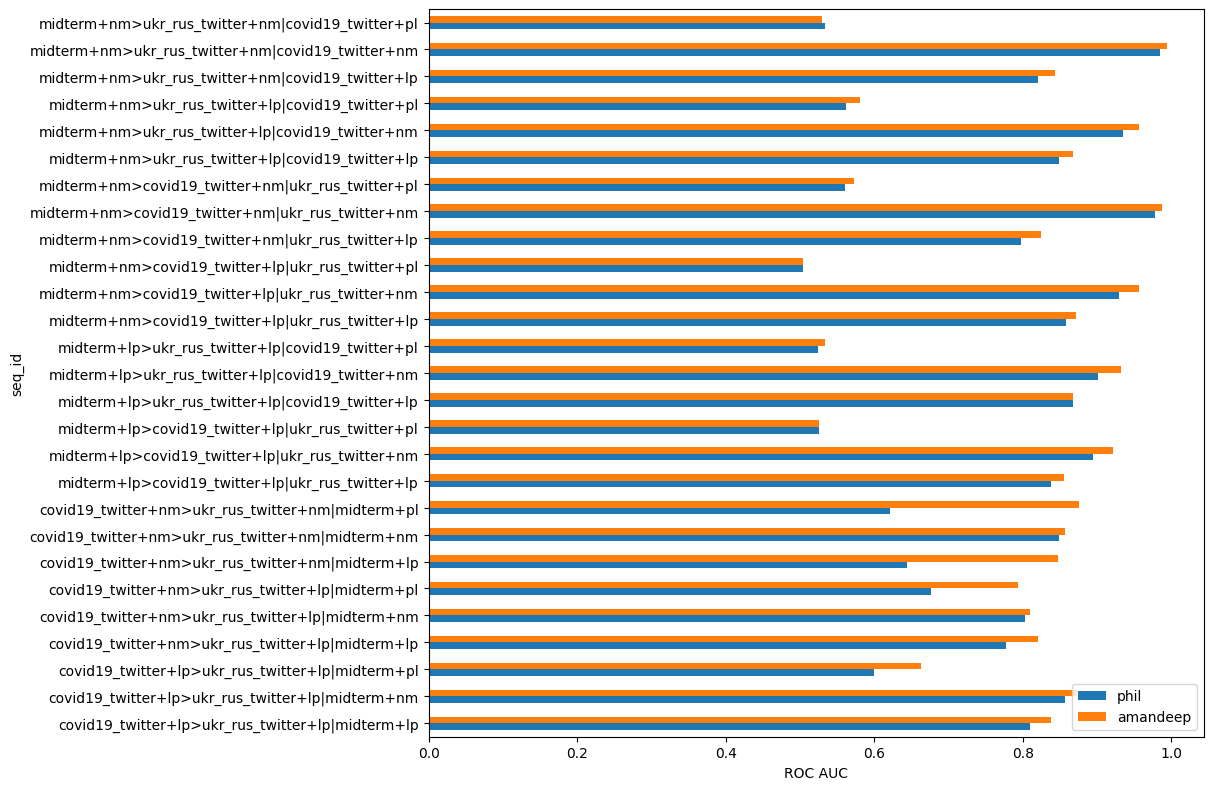

In [1585]:
x = (
    tdf.loc[tdf.seq_id.isin(train2.seq_id), ["seq_id", "n_shots", "test_roc_auc"]]
    .rename(columns={"test_roc_auc": "auc"})
)

y = (
    train2.loc[
        train2.seq_id.isin(tdf.seq_id) & train2.shots.eq(5),
        ["seq_id", "n_shots", "test_roc_auc"],
    ]
    .rename(columns={"test_roc_auc": "auc"})
)

m = (
    pd.merge(x, y, on="seq_id", suffixes=("_phil", "_amandeep"))
    .sort_values("seq_id")
    .reset_index(drop=True)
)

ax = m.plot.barh(
    x="seq_id",
    y=["auc_phil", "auc_amandeep"],
    figsize=(10, max(4, 0.35 * len(m))),
)

ax.set_xlabel("ROC AUC")
ax.set_ylabel("seq_id")
ax.legend(["phil", "amandeep"])

In [1661]:
train3 = pd.read_csv('train3_apr_29.csv')
train3['auc'] = train3.test_roc_auc
train3 = train3.dropna(subset='auc')
train3['task_name'] = train3.task_name.map({
    'neighbor_matching': 'nm',
})

In [1715]:
df['auc'] = df.test_roc_auc

cols = ['dataset', 'task_name', 'shots', 'n_way']
train3['shots'] = train3.n_shots.fillna(-1).astype(int)
train3['n_way'] = train3.n_way.fillna(-1).astype(int)
df['shots'] = df.n_shots.fillna(-1).astype(int)
df['n_way'] = df.n_way.fillna(-1).astype(int)
x = df[cols].fillna('NA').apply(list, 1).fillna('NA').astype(str)
y = train3[cols].fillna('NA').apply(list, 1).fillna('NA').astype(str)

In [1728]:
print(df[x.isin(y)].dropna(subset='auc')[['prefix'] + cols + ['auc']].to_csv())

,prefix,dataset,task_name,shots,n_way,auc
0,train3_exp3_covid_nm_to_ukr_rus_nm_to_election2020_nm,election2020,nm,3,3,0.884956940185185
2,train3_exp1_midterm_nm_to_covid_nm_to_ukr_rus_nm,ukr_rus_twitter,nm,3,2,0.99230570625
4,train3_exp3_covid_nm_to_ukr_rus_nm_to_covid_political_nm,covid_political,nm,3,3,0.9165226269444444
6,train3_exp2_midterm_nm_to_ukr_rus_nm_to_covid_nm,covid19_twitter,nm,3,3,0.9978122875
8,train3_exp1_midterm_nm_to_covid_nm_to_election2020_nm,election2020,nm,3,3,0.8862653059259259
9,train3_exp3_covid_nm_to_ukr_rus_nm_to_midterm_nm,midterm,nm,3,3,0.9676111052083334
10,train3_exp3_covid_nm_to_ukr_rus_nm_to_ukr_rus_suspended_nm,ukr_rus_suspended,nm,3,3,0.9241267305555556
23,train3_exp1_midterm_nm_to_covid_nm_to_covid_political_nm,covid_political,nm,3,3,0.9297234662037036
17,train3_exp2_midterm_nm_to_ukr_rus_nm_to_ukr_rus_suspended_nm,ukr_rus_suspended,nm,3,3,0.9364147680555556
15,train3_exp2_midterm_nm_to_ukr_rus_nm_to_election2020_nm,election2020,nm,3,3,0.88589519324

In [ ]:
print(train3[y.isin(x)].dropna(subset='auc')[['prefix'] + cols].to_csv())
